
# Exercise Sheet No. 9

---

> Machine Learning for Natural Sciences, Summer 2026, Prof. Pascal Friederich, pascal.friederich@kit.edu
>
> Tutor: jonas.teufel@kit.edu
>
> **Please ask questions in the forum/discussion board and only contact the Tutor when there are issues with the grading**
---

**Topic**: This exercise sheet will introduce you to machine learning on graphs. We'll implement graph convolutional networks (GCNs) from scratch, apply them to molecular property prediction on the AqSolDB water-solubility dataset, and finally use PyTorch Geometric to build more advanced graph neural networks.

Please add here your group members' names and student IDs. 

Names: Bahram Abdullayev

IDs: 2727213

---

### ⚠️ Lecture Evaluation ⚠️

Thank you very much for participating in our lecture and exercise so far!

It would help us a lot if you could participate in the KIT evaluation of our lecture and exercise. To receive feedback from you, and to further improve the lecture and exercise in the future, please take a few minutes and participate in both survey forms.

Lecture: https://onlineumfrage.kit.edu/evasys/online.php?p=VDU1G

Exercise: https://onlineumfrage.kit.edu/evasys/online.php?p=1379M

---

In [42]:
##### DO NOT CHANGE #####

import os
import io
import sys
import csv
import random
import itertools
import textwrap
import importlib
import importlib.util
import contextlib
import hashlib
import tempfile
from collections import defaultdict
from copy import deepcopy
from typing import List, Dict, Any, Tuple, Optional

import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning.pytorch as pl

from rdkit import Chem
from rdkit.Chem import Draw

plt.style.use('default')


def hashcheck(value: str) -> str:
    """
    Computes the hash of a string.
    """
    return hashlib.sha256(value.encode()).hexdigest()[:16]
import urllib3.util.connection

# Force IPv4 for outbound downloads. bwsyncandshare.kit.edu's AAAA record
# points to an IPv6 endpoint that is unreachable from many networks (including
# bwJupyter); Python's HTTP clients don't implement Happy Eyeballs and would
# otherwise wait the full TCP timeout (~120s) before falling back to v4.
urllib3.util.connection.HAS_IPV6 = False



def nextcloud_download(url: str, raw: bool = False) -> str:
    """
    Downloads the content of a file from a nextcloud server and returns 
    it eithers as a string or a bytes object if the ``raw`` flag is set.
    """
    response = requests.get(f'{url}/download')
    content = response.content
    if not raw:
        content = content.decode('utf-8')
    
    return content


def nextcloud_import(url: str, name: str = 'module') -> 'Module':
    """
    Downloads the content of a python module file from a nextcloud server 
    and returns the imported module instance.
    """
    with tempfile.TemporaryDirectory() as path:
        file_path = os.path.join(path, f'{name}.py')
        with open(file_path, 'w') as file:
            content = nextcloud_download(url)
            file.write(content)
        
        spec = importlib.util.spec_from_file_location(name, file_path)
        module = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(module)
        
        return module



##### DO NOT CHANGE #####

In [43]:
##### DO NOT CHANGE #####
   

utils = nextcloud_import('https://bwsyncandshare.kit.edu/s/ZBkPiGd9HnDqC4g')


##### DO NOT CHANGE #####

# 9 Machine Learning for Graphs


## 9.1 🕸️ Graph Theory

From [wikipedia](https://en.wikipedia.org/wiki/Graph_theory): "In mathematics, graph theory is the study of graphs, which are mathematical structures used to model pairwise relations between objects. A graph in this context is made up of vertices (also called nodes or points) which are connected by edges (also called links or lines). A distinction is made between undirected graphs, where edges link two vertices symmetrically, and directed graphs, where edges link two vertices asymmetrically. Graphs are one of the principal objects of study in discrete mathematics."

In one restricted but very common sense of the term, a graph is an ordered pair $G = ( V , E )$ comprising:

* The vertex set $V$ of vertices (also called nodes or points);
* The edge set $E\subseteq \{ \{x, y\} \mid x, y \in V \}$ edges (also called links or lines), which are unordered pairs of vertices (that is, an edge is associated with two distinct vertices).

To avoid ambiguity, this type of object may be called precisely an undirected simple graph. 

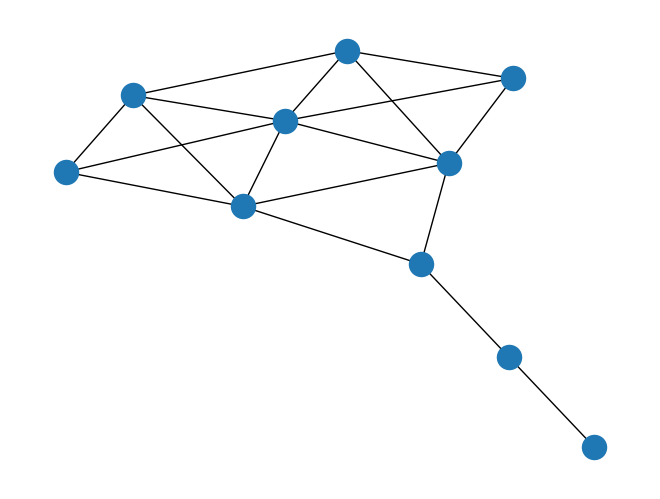

In [44]:
##### DO NOT CHANGE #####
# Example of a graph
G = nx.krackhardt_kite_graph()
nx.draw(G, pos=nx.kamada_kawai_layout(G))

##### DO NOT CHANGE #####

**The Adjacency Matrix.** The connectivity of a graph with $N$ nodes is most commonly captured by its $N \times N$ *adjacency matrix* $A$. Each entry $A_{ij}$ describes the connection between node $i$ and node $j$: for a simple *unweighted* graph this is just a binary value which is $1$ if the two nodes are connected by an edge and $0$ otherwise. For a *weighted* graph, where every edge carries a numeric weight, we instead store the corresponding *edge weight* at that position, so that $A_{ij}$ holds the weight of the edge between nodes $i$ and $j$ (and stays $0$ wherever there is no edge). Because the edges of an undirected graph have no direction, the same value applies to both $A_{ij}$ and $A_{ji}$, which makes the adjacency matrix symmetric. The diagonal entries $A_{ii}$ are $0$, since a node is not connected to itself — an assumption we will revisit later, when graph convolutions deliberately add self-loops.

## 9.2 Graph convolutional neural networks

Graph convolutional neural networks are a natural extension of CNNs for graph-structured data. A simple but efficient Graph Neural Network was introduced in ["Semi-Supervised Classification with Graph Convolutional Networks"](https://arxiv.org/abs/1609.02907) by Kipf et al. (2016). Below is a description of the model and its applications taken are from https://tkipf.github.io/graph-convolutional-networks/. We will implement this model and test it on some graph data.

**Definitions.** Currently, most graph neural network models have a somewhat universal architecture in common. We will refer to these models as Graph Convolutional Networks (GCNs); convolutional, because filter parameters are typically shared over all locations in the graph (or a subset thereof as in [Duvenaud et al., NIPS 2015](https://proceedings.neurips.cc/paper/2015/hash/f9be311e65d81a9ad8150a60844bb94c-Abstract.html)).

For these models, the goal is then to learn a function of signals/features on a graph $G = (V, E)$ which takes as input:

* A feature description $x_i$ for every node $i$; summarized in a $N\times D$ feature matrix $X$ ($N$: number of nodes, $D$: number of input features)
* A representative description of the graph structure in matrix form; typically in the form of an [adjacency matrix](https://en.wikipedia.org/wiki/Adjacency_matrix) $A$ (or some function thereof)

and produces a node-level output $Z$ (an $N\times F$ feature matrix, where $F$ is the number of output features per node). Graph-level outputs can be modeled by introducing some form of pooling operation (see, e.g. [Duvenaud et al., NIPS 2015](https://proceedings.neurips.cc/paper/2015/hash/f9be311e65d81a9ad8150a60844bb94c-Abstract.html)).

Every neural network layer can then be written as a non-linear function

$$H^{(l+1)}=f(H^{(l)}, A),$$

with $H^{(0)}=X$ and $H^{(L)}=Z$ (or $z$ for graph-level outputs), $L$ being the number of layers. The specific models then differ only in how $f(⋅,⋅)$ is chosen and parameterized.

**The GCN Layer.** As an example, let's consider the following very simple form of a layer-wise propagation rule:

$$f(H^{(l)},A)= g(AH^{(l)}W^{(l)}),$$

where $W^{(l)}$ is a weight matrix for the $l$-th neural network layer and $g(⋅)$ is a non-linear activation function like the ReLU. Despite its simplicity this model is already quite powerful.

But first, let us address two limitations of this simple model: multiplication with $A$ means that, for every node, we sum up all the feature vectors of all neighboring nodes but not the node itself (unless there are self-loops in the graph). We can "fix" this by enforcing self-loops in the graph: we simply add the identity matrix to $A$.

The second major limitation is that $A$ is typically not normalized and therefore the multiplication with $A$ will completely change the scale of the feature vectors proportional to a node's degree. Normalizing $A$ such that all rows sum to one, i.e. $D^{−1}A$, where $D$ is the diagonal node degree matrix, gets rid of this problem. Multiplying with $D^{−1}A$ now corresponds to taking the average of neighboring node features. In practice, dynamics get more interesting when we use a symmetric normalization, i.e. $D^{−\frac{1}{2}} A D^{−\frac{1}{2}}$ (as this no longer amounts to mere averaging of neighboring nodes). Combining these two tricks, we essentially arrive at the propagation rule introduced in [Kipf & Welling](https://arxiv.org/abs/1609.02907) (ICLR 2017):

$$f(H^{(l)},A)=g \, ( \hat{D}^{−\frac{1}{2}} \hat{A} \hat{D}^{−\frac{1}{2}} H^{(l)}W^{(l)}),$$

with $\hat{A}=A+I$, where $I$ is the identity matrix and $\hat{D}$ is the diagonal node degree matrix of $\hat{A}$.

**A Simple Example.** To gain a better understanding of how the GCN update rule can be implemented, we are first going to look at how all the different elements of the update function evaluate for the following simple example graph ``g``. This graph consists of only 3 nodes which are connected in a circular pattern and can be visualized as a kind of triangle pattern. Each node of the graph is associated with a two-element feature vector (e.g. [0, 1] or [1, 1]) which we'll consider as the input features $X$. Additionally, the graph has *weighted* edges where each edge is associated with a single edge weight value.

visualization of the example graph:


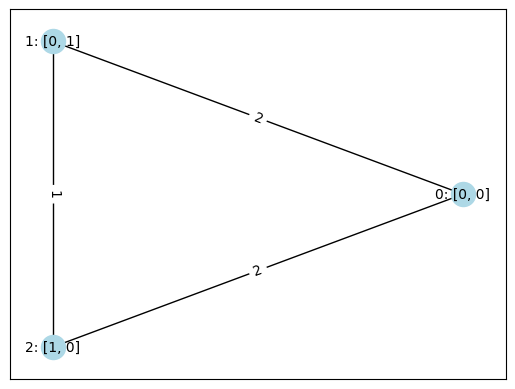

In [45]:
##### DO NOT CHANGE #####
g = nx.Graph()

# We want the graph to have 3 nodes
g.add_node(0, features=[0, 0])
g.add_node(1, features=[0, 1])
g.add_node(2, features=[1, 0])

# and those nodes should be connected in a triangle pattern
g.add_edge(0, 1, weight=2)
g.add_edge(1, 2, weight=1)
g.add_edge(2, 0, weight=2)

print('visualization of the example graph:')
pos = nx.circular_layout(g)
nx.draw_networkx_nodes(g, pos, node_color='lightblue')
nx.draw_networkx_edges(g, pos)

node_labels = {index: f'{index}: {features}' for index, features in nx.get_node_attributes(g, 'features').items()}
nx.draw_networkx_labels(g, pos, labels=node_labels, font_size=10)

edge_labels = nx.get_edge_attributes(g, 'weight')
nx.draw_networkx_edge_labels(g, pos, edge_labels=edge_labels)

plt.show()

##### DO NOT CHANGE #####

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.1 (2 points).</strong> Manually create numpy arrays corresponding to the node feature matrix $X$ and the node adjacency matrix $A$ for the previously introduced example graph into the corresponding variables <code>node_attributes</code> and <code>node_adjacency</code>. For this purpose, use the integer node indices shown in the illustration above as the corresponding row/column indices of these matrices.
</div>

In [46]:
# TASK: Fill in the node features matrix and adjacency matrix for the previously 
#       introduced graph.

# HINT: Recall how edge weights are included into an adjacency matrix!

node_attributes: np.ndarray = None
node_adjacency: np.ndarray = None

# YOUR CODE HERE
node_attributes = np.array([
    [0, 0],  # node 0
    [0, 1],  # node 1
    [1, 0],  # node 2
])

node_adjacency = np.array([
    [0, 2, 2],
    [2, 0, 1],
    [2, 1, 0],
])

In [47]:
##### DO NOT CHANGE #####
# ID: test-9-1-matrices - possible points: 2

assert isinstance(node_attributes, np.ndarray)
assert len(node_attributes.shape) == 2, 'node attributes need to be 2d matrix'
assert np.isclose(np.sum(node_attributes), 2), 'node attributes likely incorrect'

assert isinstance(node_adjacency, np.ndarray)
assert len(node_adjacency.shape) == 2, 'adjacency needs to be 2d matrix'
assert np.isclose(np.sum(node_adjacency), 10), 'node adjacency likely incorrect'
assert np.isclose(node_adjacency, node_adjacency.T).all(), 'adjacency matrix needs to be symmetrical'

# NOTE: The hidden tests will check for the exact values of the numpy arrays


##### DO NOT CHANGE #####

**Node Degree Matrix.** Another important part of the GCN update function is the diagonal node degree matrix $D$, which is used to normalize the adjacency matrix. At each diagonal position, this matrix should have the cumulative node degree (the sum of the incident edge weights) of the node with that corresponding index. Note that the full GCN propagation rule introduced below actually uses $\hat{D}$, the degree matrix of $\hat{A} = A + I$ (i.e. computed *with* the added self-loops), rather than the $D$ of the plain adjacency matrix $A$. In this task we build $D$ (and $D^2$) for the plain $A$ purely to practice the construction; $\hat{D}$ follows the exact same recipe applied to $\hat{A}$.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.2 (2 points).</strong> Manually fill in the diagonal node degree matrix $D$ for the example graph into the corresponding variable <code>node_degrees</code>. Additionally compute the squared node degrees matrix $D^2$ to populate the <code>node_degrees_squared</code> variable.
</div>

In [48]:
node_degrees = np.array([
    [4, 0, 0],
    [0, 3, 0],
    [0, 0, 3],
])

node_degrees_squared = np.array([
    [16, 0, 0],
    [0, 9, 0],
    [0, 0, 9],
])

In [49]:
##### DO NOT CHANGE #####
# ID: test-9-2-node-degrees - possible points: 2

assert isinstance(node_degrees, np.ndarray)
assert len(node_degrees.shape) == 2, 'node degrees should be 2d matrix'
assert np.isclose(node_degrees, node_degrees.T).all(), 'node degrees matrix should be symmetrical'

assert isinstance(node_degrees_squared, np.ndarray)
assert len(node_degrees_squared.shape) == 2, 'node degrees squared should be 2d matrix'
assert np.isclose(node_degrees_squared, node_degrees_squared.T).all(), 'node degrees squared should be symmetrical'

# NOTE: The hidden tests will check for the exact values of the numpy arrays


##### DO NOT CHANGE #####

**GCN Implementation.** As previously introduced, the *Graph Convolutional Network (GCN)* layers can be implemented with the following update rule

$$H^{(l+1)} = f(H^{(l)},A)=g \, ( \hat{D}^{−\frac{1}{2}} \hat{A} \hat{D}^{−\frac{1}{2}} H^{(l)}W^{(l)}),$$

which calculates the updated node feature matrix $H^{(l+1)}$ based on the previous layers's node features $H^{(l)}$ and the adjacency information $A$ of the graph. Specifically, the formula uses the *modified adjacency matrix* 

$$
\hat{A} = A + I
$$

to which we append the identity matrix $I$ to introduce self-loops to the graph structure. This adjacency matrix is normalized by using the diagonal node degree matrix $\hat{D}$ of the modified adjacency matrix $\hat{A}$. Finally, the normalized adjacency matrix is multiplied by the previous node feature matrix $H^{(l)}$. This operation represents the convolution aspect of the layer, whereby node feature information is spread across all directly neighboring nodes. Finally, a learnable weight matrix $W^{(l)}$ is then applied to possibly transform the output shape into the output feature dimension.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.3 (5 points).</strong> For this task you should implement the <code>gcn_conv</code> function according to the previously described GCN update rule. The function accepts three arguments: <code>node_attributes</code> is the previous layers node feature matrix, <code>node_adjacency</code> is the graphs node adjacency matrix and <code>weights</code> is the weight matrix to apply the feature transformation. The function should return a numpy array that represents the updated node feature matrix.
</div>

In [50]:
# TASK: Use numpy operations to implement the GCN update rule into the function below.

# HINT: If at some point you encounter "inf" (infinity) values in one of the 
#       arrays simply replace them with 0, using the np.where function, for example.

# HINT: Use the RELU activation function as the final non-linear transformation 
#       of your implementation. Numpy doesn't directly implement a relu function 
#       but can easily recreated with the np.maximum function.

def gcn_conv(node_attributes: np.ndarray, 
             node_adjacency: np.ndarray,
             weights: np.ndarray,
             ) -> np.ndarray:
    """
    Given the ``node_attributes`` matrix of shape (num_nodes, num_features_in), 
    the ``node_adjacency`` matrix of shape (num_nodes, num_nodes) and the ``weights`` 
    matrix of shape (num_features_in, num_features_out), this function should return 
    the updated node feature matrix of the shape (num_nodes, num_features_out)
    """
    
    # YOUR CODE HERE
    modified_adjacency = (
        node_adjacency + np.eye(node_adjacency.shape[0])
    )

    modified_degrees = np.sum(modified_adjacency, axis=1)

    with np.errstate(divide='ignore'):
        inverse_sqrt_degrees = modified_degrees ** (-0.5)

    inverse_sqrt_degrees = np.where(
        np.isinf(inverse_sqrt_degrees),
        0,
        inverse_sqrt_degrees
    )

    inverse_sqrt_degree_matrix = np.diag(
        inverse_sqrt_degrees
    )

    normalized_adjacency = (
        inverse_sqrt_degree_matrix
        @ modified_adjacency
        @ inverse_sqrt_degree_matrix
    )

    updated_node_attributes = (
        normalized_adjacency
        @ node_attributes
        @ weights
    )

    return np.maximum(updated_node_attributes, 0)

In [51]:
##### DO NOT CHANGE #####
# ID: test-9-3-gcn-conv - possible points: 5

# We'll check the correctnes of the implementation for one concrete example:
_node_attributes = np.array([
    [1, 0],
    [0, 1],
    [1, 0],
    [1, 0],
])
_node_adjacency = np.array([
    [0, 1, 2, 0],
    [1, 0, 1, 1],
    [2, 1, 0, 0],
    [0, 1, 0, 0],
])
_weights = np.array([
    [1, -1, 1],
    [-1, 0, 1],
])

_output = gcn_conv(
    _node_attributes,
    _node_adjacency,
    _weights,
)

assert isinstance(_output, np.ndarray)
assert _output.shape == (4, 3), 'output shape incorrect'
assert np.isclose(np.sum(_output), 5.707, atol=0.1), 'output likely incorrect'

# A second, smaller example you can verify by hand: an unweighted line graph
# 0 - 1 - 2 with identity weights. Here the layer just performs the symmetric-
# normalized aggregation of the (unchanged) node features over each node's
# neighborhood (including its own self-loop), so you can sanity-check the
# individual entries against the GCN update rule.
_node_attributes_2 = np.array([
    [1, 2],
    [0, 1],
    [2, 0],
])
_node_adjacency_2 = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0],
])
_weights_2 = np.eye(2)

_output_2 = gcn_conv(_node_attributes_2, _node_adjacency_2, _weights_2)

_expected_2 = np.array([
    [0.5000, 1.4082],
    [1.2247, 1.1498],
    [1.0000, 0.4082],
])
assert _output_2.shape == (3, 2), 'output shape incorrect for the second example'
assert np.allclose(_output_2, _expected_2, atol=1e-3), 'output values incorrect for the second example'

# NOTE: The hidden tests additionally compare your implementation element-wise
#       against a reference implementation on a range of randomly generated
#       graphs (different sizes, weighted edges, isolated nodes and negative
#       values that exercise the ReLU).


##### DO NOT CHANGE #####

**Applying Graph Convolutions.** After implementing the graph convolutional layer, we want to see how this layer actually works now. As it is already indicated in its name, the GCN graph network layers apply a convolution-like operation on the node attributes of the graph. In practice, this means that the feature information of any node is shared with its immediately neighboring nodes in each convolutional step. The simplest intuition for this information sharing is a *weighted aggregation*: in each step a node's updated features become a normalized combination of its own features and those of its immediate neighbors. (Plainly averaging the neighbors corresponds to the simpler $D^{-1}A$ variant; the symmetric normalization $\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}$ that we actually implemented is a *normalized weighted aggregation* rather than a strict average — as noted in the previous section.) By applying multiple of these operations in sequence it is therefore possible to propagate information throughout the (majority of) the graph.

By introducing the learnable weight matrices we can furthermore control *how* exactly this process of information sharing works and can therefore (hopefully) learn a function that aggregates and processes useful information from different areas of the graph that we can then ultimately use to solve some downstream prediction task.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.4 (2 points).</strong> In this task we want to look at a concrete visual example of how these graph convolutions can work. The given example graph <code>g_color</code> is a small graph with 8 nodes and some undirected, unweighted edges. Each node is associated with 3-element feature vectors, containing values in the interval $[0, 1]$, representing RGB color values [R, G, B] (e.g [1, 0, 0] is red, [0, 1, 0] is green and [1, 1, 1] is white). Your task is to apply <strong>3</strong> gcn operations on this graph using the same pre-defined weight matrix <code>weights</code> that is given below. After the 3 convolutions, report the new color code values of the node with <em>node index 2</em> in the variable <code>color_2</code>. <strong>Note:</strong> <code>color_2</code> must be a plain Python <code>list</code> of <code>float</code> values &mdash; a numpy array will not pass the tests (use <code>.tolist()</code> to convert).
</div>

visualization of the color graph:


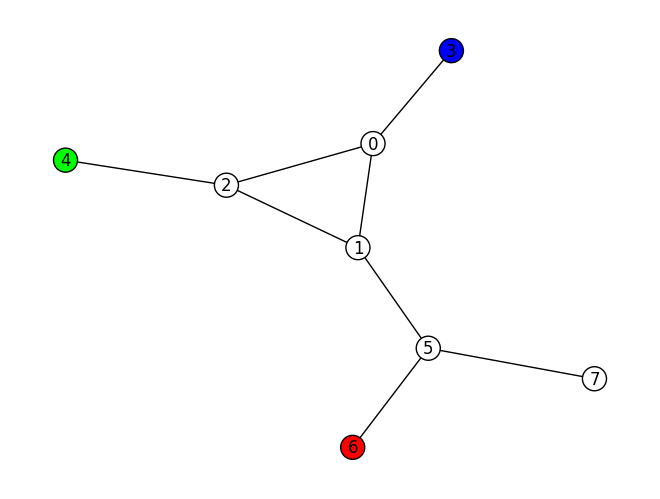

In [52]:
##### DO NOT CHANGE #####
g_color = nx.Graph()

## -- Graph Nodes --
# Graph consists of mostly "white" (1, 1, 1) nodes and some colored nodes
g_color.add_node(0, color=[1, 1, 1])
g_color.add_node(1, color=[1, 1, 1])
g_color.add_node(2, color=[1, 1, 1])
g_color.add_node(3, color=[0, 0, 1])
g_color.add_node(4, color=[0, 1, 0])
g_color.add_node(5, color=[1, 1, 1])
g_color.add_node(6, color=[1, 0, 0])
g_color.add_node(7, color=[1, 1, 1])

## -- Graph Edges --
# The graph has a white triangle in the middle with some branches as the sides
g_color.add_edge(0, 1)
g_color.add_edge(1, 2)
g_color.add_edge(2, 0)
g_color.add_edge(0, 3)
g_color.add_edge(2, 4)
g_color.add_edge(1, 5)
g_color.add_edge(5, 6)
g_color.add_edge(5, 7)

## -- Graph Visualization --
# We can use this function to visualize the graph after different stages of convolution
def draw_graph(graph: nx.Graph):
    node_colors = []
    for value in nx.get_node_attributes(graph, 'color').values():
        value = np.array(value)
        value[value > 1] = 1
        node_colors.append(value.tolist())
        
    return nx.draw_kamada_kawai(graph, with_labels=True, node_color=node_colors, edgecolors='black')

print('visualization of the color graph:')
draw_graph(g_color)

##### DO NOT CHANGE #####

visualization of the color graph after the convolutions:


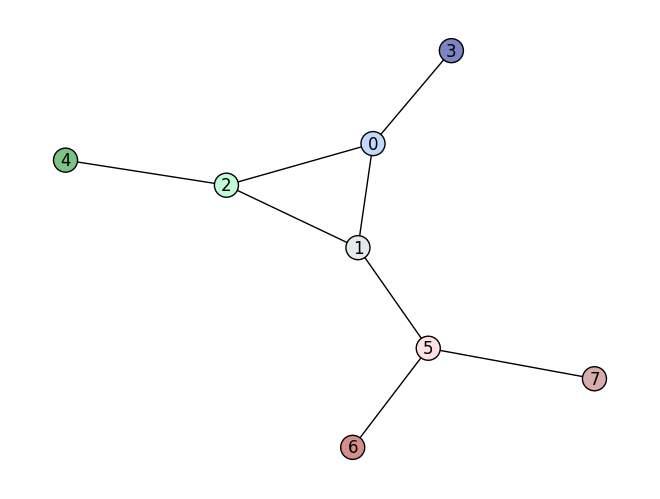

In [53]:
weights = 1.0 * np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
])

# TASK: Use the previous implementation of the GCN update rule and the given weight 
#       matrix to determine the new node features after subjecting the given g_color 
#       to 3 gcn update steps.

# You may use this graph instance (copy of the original color graph) to update after 
# the individual convolutional steps.
g_current: nx.Graph = deepcopy(g_color)
color_2: list[float] = None

# HINT: Look into the networkx documentation how to extract the adjacenycy matrix 
#       and the node feature matrix from a "Graph" object and also how to update 
#       the features of the Graph object after each convolutional step.
    
# YOUR CODE HERE
node_order = list(g_current.nodes())

node_adjacency = nx.to_numpy_array(
    g_current,
    nodelist=node_order,
    dtype=float
)

node_attributes = np.array([
    g_current.nodes[node]["color"]
    for node in node_order
], dtype=float)

for _ in range(3):
    node_attributes = gcn_conv(
        node_attributes=node_attributes,
        node_adjacency=node_adjacency,
        weights=weights
    )

    updated_colors = {
        node: node_attributes[index].tolist()
        for index, node in enumerate(node_order)
    }

    nx.set_node_attributes(
        g_current,
        updated_colors,
        "color"
    )

color_2 = node_attributes[node_order.index(2)].tolist()

# HINT: Dont forget to update the "color" attributes of the g_current graph object
#       at the end of the convolutions so that the final results will be visible in
#       the visualization of the graph.

print('visualization of the color graph after the convolutions:')
draw_graph(g_current)

For this example, we can easily observe the basic working principle of the GCN update rule! The original graph consisted mostly of white nodes with 3 distinctly colored nodes. After 3 convolutions, all the previously white nodes have gained some slight coloration, while the originally colored nodes have slightly faded in their intensity.

In [54]:
##### DO NOT CHANGE #####
# ID: test-9-4-conv - possible points: 2

assert isinstance(g_current, nx.Graph)

assert isinstance(color_2, list), 'solution needs to be a list and not a numpy array'
assert all([isinstance(c, float) for c in color_2]), 'solution elements need to be floats'
assert len(color_2) == 3, 'solution needs to be a valid 3 element color code'
assert hashcheck(','.join([f'{v:.2f}' for v in color_2])) == '2e0401c6a66a6b15', 'color_2 likely incorrect'

# NOTE: The hidden tests will test for the exact values of the color code of node "2"
#       (with 3 decimal points accuracy)


##### DO NOT CHANGE #####

## 9.3 ⚗️ Molecular Graphs

**Molecules as Graphs.** Another important application domain for graph neural networks is chemistry and material science. This is because [molecules](https://en.wikipedia.org/wiki/Molecule) can also be represented as graph structures. Molecules can be defined as a set of atoms that is held in a close ordered configuration by set of attractive forces also called chemical bonds. Therefore, we could define all the atoms in a molecule as the nodes of a molecular graph and the chemical bonds between individual atoms as the graph edges.

**Molecular Representations.** A full graph structure, consisting of nodes and edges, is somewhat unwieldy to represent molecules - especially in an easily human-readable manner. Consequently, different methods of representing and communicating such molecular graph structures have been established. One important representation is the [Simplified molecular-input line-entry system (SMILES)](https://en.wikipedia.org/wiki/Simplified_molecular-input_line-entry_system) method which represents each molecule as a single string consisting of the abbreviated atom names and a special syntax to indicate which atoms are connected via bonds. The following image shows a rough illustration of how such a SMILES string is constructed from the molecular graph structure.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/0/00/SMILES.png/300px-SMILES.png">

In the end, every molecular graph can be reduced into one (mostly) human-readable string representation. Due to the relative efficiency und understandability of this representation, the SMILES format is one of the most common formats in which machine learning datasets for molecular property prediction are distributed. A common dataset format, for example, is to simply provide a list of the molecule's SMILES representations along with the annotated target properties like this:

| smiles      | target |
|:-------------|:--------|
| CCO         | -0.2   |
| C1=CC=CC=C1 | 3.2    |
| CC(CO)C=N   | -1.2   |
| ...         |        |

**Chem-Informatics with RDKit.** To then apply graph machine learning methods such as GNNs to property prediction datasets such as this, we need to somehow reconstruct a molecule's full graph structure given the SMILES representation. We generally don't have to implement the SMILES parsing and processing ourselves but can rather rely on large cheminformatics libraries such as [RDKit](https://www.rdkit.org/docs/). These libraries provide tools to parse the SMILES strings and construct the corresponding molecular graph structures, which can then be further converted into a format suitable to be fed to a specific machine learning model.

In terms of the actual implementation, the rdkit library provides the ``MolFromSmiles`` function that can be used to convert a SMILES string into an rdkit ``Mol`` object. Such a mol object is populated with a list of atoms and bonds that have been derived from the SMILES representation.


Molecule Object: <class 'rdkit.Chem.rdchem.Mol'>

Iterating over Molecule Atoms
 *  0 - type: <class 'rdkit.Chem.rdchem.Atom'>
 *  1 - type: <class 'rdkit.Chem.rdchem.Atom'>
 *  2 - type: <class 'rdkit.Chem.rdchem.Atom'>
 *  3 - type: <class 'rdkit.Chem.rdchem.Atom'>
 *  4 - type: <class 'rdkit.Chem.rdchem.Atom'>
 *  5 - type: <class 'rdkit.Chem.rdchem.Atom'>
 *  6 - type: <class 'rdkit.Chem.rdchem.Atom'>
 *  7 - type: <class 'rdkit.Chem.rdchem.Atom'>
 *  8 - type: <class 'rdkit.Chem.rdchem.Atom'>
 *  9 - type: <class 'rdkit.Chem.rdchem.Atom'>
 * 10 - type: <class 'rdkit.Chem.rdchem.Atom'>
 * 11 - type: <class 'rdkit.Chem.rdchem.Atom'>

Iterating over Molecule Bonds
 *  0 - type: <class 'rdkit.Chem.rdchem.Bond'>
 *  1 - type: <class 'rdkit.Chem.rdchem.Bond'>
 *  2 - type: <class 'rdkit.Chem.rdchem.Bond'>
 *  3 - type: <class 'rdkit.Chem.rdchem.Bond'>
 *  4 - type: <class 'rdkit.Chem.rdchem.Bond'>
 *  5 - type: <class 'rdkit.Chem.rdchem.Bond'>
 *  6 - type: <class 'rdkit.Chem.rdchem.Bo

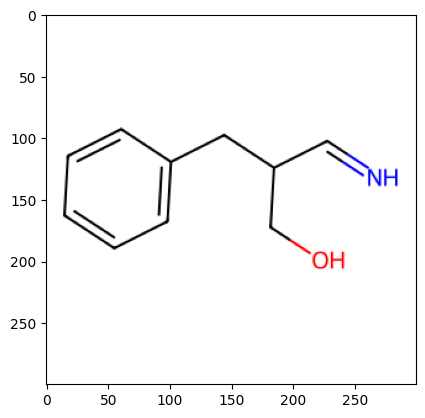

In [55]:
##### DO NOT CHANGE #####
example_smiles: str = 'C1=CC=CC=C1CC(CO)C=N'
mol = Chem.MolFromSmiles(example_smiles)
print(f'\nMolecule Object: {type(mol)}')

print(f'\nIterating over Molecule Atoms')
for atom_index, atom in enumerate(mol.GetAtoms()):
    print(f' * {atom_index:2} - type: {type(atom)}')

print(f'\nIterating over Molecule Bonds')
for bond_index, bond in enumerate(mol.GetBonds()):
    print(f' * {bond_index:2} - type: {type(bond)}')
    
print('Visualization of the molecule:')
molecule = Chem.MolFromSmiles(example_smiles)
img = Draw.MolToImage(molecule)
plt.imshow(np.array(img))

##### DO NOT CHANGE #####

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.5 (3 points).</strong> In this exercise, the goal is to convert the <code>Mol</code> molecular graph structure obtained from RDKit into a format that can be directly processed using the previously introduced GCN neural network layers. For this purpose, your task is to implement the following <code>graph_from_smiles</code> function. This function receives the <code>smiles</code> string as the single argument and is supposed to return the following tuple of values:
<ul>
<li><code>node_attributes</code>: The node feature matrix of the shape (number of atoms, 8). Spefically, we want the corresponding node feature vector of a node to be a <a href="https://en.wikipedia.org/wiki/One-hot">One-Hot Encoding</a> of the atom type (carbon, oxygen, nitrogen, ...). In total, we want to differentiate between the <em>7 most common</em> atoms in organic chemistry with the following one-hot indices:
<ul>
<li>0 - carbon (C)</li>
<li>1 - nitrogen (N)</li>
<li>2 - oxygen (O)</li>
<li>3 - fluorine (F)</li>
<li>4 - chlorine (Cl)</li>
<li>5 - bromine (Br)</li>
<li>6 - iodine (I)</li>
<li>7 - <em>default case</em> (all others that are none of the above)</li>
</ul>
as an example, a <em>bromine</em> atom would therefore be encoded as the array <code>[0, 0, 0, 0, 0, 1, 0, 0]</code></li>
<li><code>node_adjacency</code>: The node adjacency matrix of the shape (number of atoms, number of atoms) that determines the connectivitey of the molecule - meaning whether or not two atoms are connected by a bond or not.</li>
</ul>
</div>

In [56]:
import random

# TASK: Implement the following function to create a node feature / adjacency 
#       graph representation from a molecule's SMILES string.

# HINT: How to determine the type of an atom within the molecule you can find in 
#       the RDKIT documentation.

# HINT: For the sake simplicity we'll disregard the different bond types here,  
#       resulting in graphs with unweighted edges. This simplifies the adjacency 
#       matrix that now only conists of binary values that are either 0 or 1.

def graph_from_smiles(smiles: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Given the ``smiles`` string, this function returns a tuple consisting of the 
    node feature matrix of shape (num_atoms, 8) and the adjacency matrix of the 
    shape (num_atoms, num_atoms) based on the molecular bonds.
    """
    
    mol = Chem.MolFromSmiles(smiles)
    
    # YOUR CODE HERE
    atom_indices = {
        "C": 0,
        "N": 1,
        "O": 2,
        "F": 3,
        "Cl": 4,
        "Br": 5,
        "I": 6,
    }

    num_atoms = mol.GetNumAtoms()

    node_attributes = np.zeros(
        (num_atoms, 8),
        dtype=float
    )

    for atom in mol.GetAtoms():
        atom_index = atom.GetIdx()
        atom_symbol = atom.GetSymbol()

        feature_index = atom_indices.get(atom_symbol, 7)
        node_attributes[atom_index, feature_index] = 1.0

    node_adjacency = np.zeros(
        (num_atoms, num_atoms),
        dtype=float
    )

    for bond in mol.GetBonds():
        atom_index_1 = bond.GetBeginAtomIdx()
        atom_index_2 = bond.GetEndAtomIdx()

        node_adjacency[atom_index_1, atom_index_2] = 1.0
        node_adjacency[atom_index_2, atom_index_1] = 1.0

    return node_attributes, node_adjacency

In [57]:
##### DO NOT CHANGE #####
# ID: test-9-5-molecule-process - possible points: 3

_test_list = [
    ('CCO', 3),
    ('C(CN)CCl', 5),
]

for _smiles, _num_atoms in _test_list:

    node_features, node_adjacency = graph_from_smiles(_smiles)

    assert isinstance(node_features, np.ndarray)
    assert isinstance(node_adjacency, np.ndarray)

    assert node_features.shape == (_num_atoms, 8), f'node feature shape {node_features.shape} incorrect'
    assert node_adjacency.shape == (_num_atoms, _num_atoms), f'adjacency matrix shape {node_adjacency.shape} incorrect'

    # more specific checks for the node freatures
    assert np.isclose(np.max(node_features), 1), f'one-hot encoding cant have values larger than 1'
    assert np.isclose(np.min(node_features), 0), f'one-hot encoding cant have values smaller than 0'
    assert np.isclose(np.sum(node_features), _num_atoms), f'each node can only have a single one-hot value'

    # more specific checks for the adjacency matrix, such as symmetry
    assert np.isclose(np.max(node_adjacency), 1), f'adjacency matrix cant have values larger than 1'
    assert np.isclose(np.min(node_adjacency), 0), f'adjacency matrix cant have values smaller than 0'
    assert np.array_equal(node_adjacency, node_adjacency.T), f'adjacency matrix needs to be diagonally symmetrical'

# A fully worked example you can check your encoding against. The molecule
# FC(Cl)(Br)I is a single central carbon (atom 1) bonded to F (atom 0),
# Cl (atom 2), Br (atom 3) and I (atom 4). Recall that the one-hot feature
# columns are ordered [C, N, O, F, Cl, Br, I, default].
_features, _adjacency = graph_from_smiles('FC(Cl)(Br)I')

_expected_features = np.array([
    [0, 0, 0, 1, 0, 0, 0, 0],  # atom 0: F
    [1, 0, 0, 0, 0, 0, 0, 0],  # atom 1: C
    [0, 0, 0, 0, 1, 0, 0, 0],  # atom 2: Cl
    [0, 0, 0, 0, 0, 1, 0, 0],  # atom 3: Br
    [0, 0, 0, 0, 0, 0, 1, 0],  # atom 4: I
])
_expected_adjacency = np.array([
    [0, 1, 0, 0, 0],
    [1, 0, 1, 1, 1],
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0],
])
assert _features.shape == (5, 8), f'node feature shape {_features.shape} incorrect'
assert np.array_equal(_features, _expected_features), 'node feature one-hot encoding incorrect for FC(Cl)(Br)I'
assert np.array_equal(_adjacency, _expected_adjacency), 'adjacency matrix incorrect for FC(Cl)(Br)I'

# NOTE: The hidden tests additionally compare the exact node feature and adjacency
#       arrays against a reference implementation for a number of molecules that
#       cover every atom type (incl. the default slot) and both branched and ring
#       connectivity.


##### DO NOT CHANGE #####

**Graph Batching.** The previously implemented function ``graph_from_smiles`` directly converts the SMILES string representation of a molecule into a node feature matrix and an adjacency matrix. Together, both of these elements can be used as inputs to the previously implemented ``GCN`` network layer. As is usual in neural network training, we would like to process these graph representations in *batches* where multiple graphs are passed through the network at once. However, similarly as with Recurrent Neural Networks (RNNs) we run into the problem that these graphs usually have *different sizes* and can therefore not directly be stacked into a single tensor.

**Input Padding and Masking.** One common solution to this problem is to use *padding* and *masking* to fit the differently sized graph structures into a common tensor shape. For this purpose we choose some maximum number of nodes $N_{\mathrm{max}}$ such that *all* the graphs in the target dataset have less nodes than this number. Then we simply embedd all graph feature and adjacency matrices into larger matrices of shapes $(N_{\mathrm{max}}, F)$ and $(N_{\mathrm{max}}, N_{\mathrm{max}})$ and set all the unused entries to zero. In addition to this we also need some way to then recover the actual node features from these larger arrays. We'll do this by additionally maintining a binary mask matrix $M$ which has 1 entries only for those matrix elements where the feature matrix has actually meaningful entries.

Consider the following constructed example to illustrate this idea. We'll consider the case in which we want to batch two graphs which are given by the features matrices $X_1, X_2$ and adjacency matrices $A_1, A_2$. Graph 1 consists of 2 nodes and Graph 2 consists of 3 nodes

$$
X_1 = \begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
\end{bmatrix} \quad
A_1 = \begin{bmatrix}
0 & 1 \\
1 & 0 \\
\end{bmatrix}
$$

$$
X_2 = \begin{bmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & 0 & 1 \\
\end{bmatrix} \quad
A_2 = \begin{bmatrix}
0 & 1 & 1 \\
1 & 0 & 0 \\
1 & 0 & 0 \\
\end{bmatrix}
$$

We can now choose $N_{\mathbf{max}} = 4$, which is guaranteed larger then the number of nodes of both of our graphs. We get the following padded arrays as well as the feature masks that contain the information about which parts of the feature arrays now actually contain the relevant information:

$$
\hat{X}_1 = \begin{bmatrix}
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 0 & 0 \\
0 & 0 & 0 \\
\end{bmatrix} \quad
\hat{A}_1 = \begin{bmatrix}
0 & 1 & 0 & 0\\
1 & 0 & 0 & 0\\
0 & 0 & 0 & 0\\
0 & 0 & 0 & 0\\
\end{bmatrix} \quad
M_1 = \begin{bmatrix}
1 \\
1 \\
0 \\
0 \\
\end{bmatrix}
$$

$$
\hat{X}_2 = \begin{bmatrix}
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & 0 & 1 \\
0 & 0 & 0 \\
\end{bmatrix} \quad
\hat{A}_2 = \begin{bmatrix}
0 & 1 & 1 & 0\\
1 & 0 & 0 & 0\\
1 & 0 & 0 & 0\\
0 & 0 & 0 & 0\\
\end{bmatrix} \quad
M_2 = \begin{bmatrix}
1 \\
1 \\
1 \\
0 \\
\end{bmatrix}
$$

Since these arrays now have the same shape we can easily stack them along an additional tensor to create the batched feature tensor $X$ with shape $(2, N_{\mathrm{max}}, 3)$ and the batched adjacency tensor $A$ with shape $(2, N_{\mathrm{max}}, N_{\mathrm{max}})$, such as like this:

```python
X_batch = np.stack([X_hat_1, X_hat_2], axis=0) # shape: (2, 4, 3)
A_batch = np.stack([A_hat_1, A_hat_2], axis=0) # shape: (2, 4, 4)
```

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.6 (2 points).</strong> In this exercise you need to implement the <code>batch_graphs</code> function. The function takes a list of individual tuples consisting of the <code>node_features</code> and <code>node_adjacency</code> numpy arrays as the input and is supposed to return a tuple of 3 <code>torch.Tensor</code> instances:
<ul>
<li>batched feature tensor $X$ with shape <code>(batch_size, n_max, num_features)</code></li>
<li>batched feature mask tensor $M$ with shape <code>(batch_size, n_max, 1)</code></li>
<li>batched adjacency tensor $A$ with shape <code>(batch_size, n_max, n_max)</code></li>
</ul>
</div>

In [58]:
def batch_graphs(graph_tuples: list[tuple[np.ndarray, np.ndarray]],
                 N_max: int
                 ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Given the list of ``graph_tuples`` (node_attributes, node_adjacency) of differently 
    sized graphs and an integer number ``N_max`` that determines the maximum number of 
    of nodes across the given graphs, this fucntion should return a tuple of 3 torch 
    tensors:
    - the batched node attributes tensor with shape (num_graphs, N_max, num_features)
    - the batched node mask matrix (num_graphs, N_max, 1) which consists of 
      binary values 0 and 1 that determine which columns of the node feature tensor 
      contain actual features for every element in the batch.
    - the batched node adjacency matrix (num_graphs, N_max, N_max)
    """
    
    # YOUR CODE HERE
    if len(graph_tuples) == 0:
        raise ValueError("graph_tuples must contain at least one graph")

    num_features = graph_tuples[0][0].shape[1]

    padded_features_list = []
    padded_masks_list = []
    padded_adjacency_list = []

    for node_attributes, node_adjacency in graph_tuples:
        num_nodes = node_attributes.shape[0]

        if num_nodes > N_max:
            raise ValueError(
                f"Graph has {num_nodes} nodes, which exceeds N_max={N_max}"
            )

        padded_features = np.zeros(
            (N_max, num_features),
            dtype=np.float32
        )

        node_mask = np.zeros(
            (N_max, 1),
            dtype=np.float32
        )

        padded_adjacency = np.zeros(
            (N_max, N_max),
            dtype=np.float32
        )

        padded_features[:num_nodes, :] = node_attributes
        node_mask[:num_nodes, 0] = 1.0
        padded_adjacency[:num_nodes, :num_nodes] = node_adjacency

        padded_features_list.append(padded_features)
        padded_masks_list.append(node_mask)
        padded_adjacency_list.append(padded_adjacency)

    batched_features = torch.tensor(
        np.stack(padded_features_list, axis=0),
        dtype=torch.float32
    )

    batched_masks = torch.tensor(
        np.stack(padded_masks_list, axis=0),
        dtype=torch.float32
    )

    batched_adjacency = torch.tensor(
        np.stack(padded_adjacency_list, axis=0),
        dtype=torch.float32
    )

    return batched_features, batched_masks, batched_adjacency

In [59]:
##### DO NOT CHANGE #####
# ID: test-9-6-batch-graphs - possible points: 2

# We are going to test the batching functionality with the following two simple example
# graphs that we want to combine into batched tensors using N_max = 4
_graph_1 = (
    np.array([
        [1, 0, 0],
        [0, 1, 0]
    ]),
    np.array([
        [0, 1],
        [1, 0]
    ])
)

_graph_2 = (
    np.array([
        [1, 0, 0],
        [0, 0, 1],
        [0, 0, 1],
    ]),
    np.array([
        [0, 1, 1],
        [1, 0, 0],
        [1, 0, 0],
    ])
)

_graph_tuples = [_graph_1, _graph_2]
_N_max = 4

node_feature_batch, node_feature_mask_batch, node_adjacency_batch = batch_graphs(
    _graph_tuples,
    _N_max,
)

# node features
assert isinstance(node_feature_batch, torch.Tensor)
assert len(node_feature_batch.shape) == 3, 'batched node features need to be 3 dimensional'
assert node_feature_batch.shape == (len(_graph_tuples), _N_max, 3), f'node feature shape incorrect: {node_feature_batch.shape}'

# node feature mask
assert isinstance(node_feature_mask_batch, torch.Tensor)
assert len(node_feature_mask_batch.shape) == 3
assert node_feature_mask_batch.shape == (len(_graph_tuples), _N_max, 1), f'node feature mask shape incorrect: {node_feature_mask_batch.shape}'

# adjacency matrix
assert isinstance(node_adjacency_batch, torch.Tensor)
assert len(node_adjacency_batch.shape) == 3
assert node_adjacency_batch.shape == (len(_graph_tuples), _N_max, _N_max), f'adjacency shape incorrect: {node_adjacency_batch.shape}'

# The exact expected values for the two example graphs. Each graph is padded with
# zero-rows at the *bottom* up to N_max = 4 nodes; the mask marks the real nodes
# with a 1 and the padding rows with a 0.
_expected_features = torch.tensor([
    [[1, 0, 0], [0, 1, 0], [0, 0, 0], [0, 0, 0]],   # graph 1 (2 real nodes)
    [[1, 0, 0], [0, 0, 1], [0, 0, 1], [0, 0, 0]],   # graph 2 (3 real nodes)
], dtype=torch.float32)
_expected_mask = torch.tensor([
    [[1], [1], [0], [0]],
    [[1], [1], [1], [0]],
], dtype=torch.float32)
_expected_adjacency = torch.tensor([
    [[0, 1, 0, 0], [1, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]],
    [[0, 1, 1, 0], [1, 0, 0, 0], [1, 0, 0, 0], [0, 0, 0, 0]],
], dtype=torch.float32)

assert torch.allclose(node_feature_batch.float(), _expected_features), 'batched node features have incorrect values / padding'
assert torch.allclose(node_feature_mask_batch.float(), _expected_mask), 'node feature mask has incorrect values'
assert torch.allclose(node_adjacency_batch.float(), _expected_adjacency), 'batched adjacency has incorrect values / padding'

# NOTE: The hidden tests additionally compare all three returned tensors element-wise
#       against a reference implementation for a range of randomly generated graph
#       lists (different graph sizes, feature dimensions and N_max values).


##### DO NOT CHANGE #####

**AqsolDB Dataset.** As a practical application we'll be looking at the [AqsolDB](https://www.nature.com/articles/s41597-019-0151-1) dataset. This dataset contains roughly 10k molecule that have been annotated with continous, experimental logS values of [water solubility](https://en.wikipedia.org/wiki/Solubility). These logS values are roughly in the range $[-14, 3]$ and higher values indicate higher solubility. In the following section, we'll train a graph neural network that will predict this regression label given the molecular graph structure. Being able to accurately predict this property would be an important step to speed up the development of new drugs, for example.

In the first step we'll download the dataset and explore some example elements:

<>:8: SyntaxWarning: invalid escape sequence '\.'
<>:8: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_1075/2806103708.py:8: SyntaxWarning: invalid escape sequence '\.'
  df = df[~df['smiles'].str.contains('\.')]
[01:27:51] Explicit valence for atom # 5 N, 4, is greater than permitted
[01:27:51] Explicit valence for atom # 5 N, 4, is greater than permitted


Datasets consists of 9924 elements
Column names: index, ID, smiles, InChIKey, solubility, split
Dataframe head:
   index      ID                                   smiles  \
0      0    A-10                           Cc1cccc(C=C)c1   
1      1   A-100  Cc1cc(cc(C)c1O)C(C)(C)c2cc(C)c(O)c(C)c2   
2      2  A-1000                    O=C1CCCCCCCCCOCCCCCO1   
3      3  A-1002                   CCCCCCCCCCC(C)CCCCCCCC   
4      4  A-1003                          NC(=O)N=NC(N)=O   

                      InChIKey  solubility  split  
0  JZHGRUMIRATHIU-UHFFFAOYSA-N   -3.123150      1  
1  ODJUOZPKKHIEOZ-UHFFFAOYSA-N   -4.952869      1  
2  MKEIDVFLAWJKMY-UHFFFAOYSA-N   -3.883849      1  
3  FFVPRSKCTDQLBP-UHFFFAOYSA-N   -6.451105      1  
4  XOZUGNYVDXMRKW-UHFFFAOYSA-N   -3.546243      1  


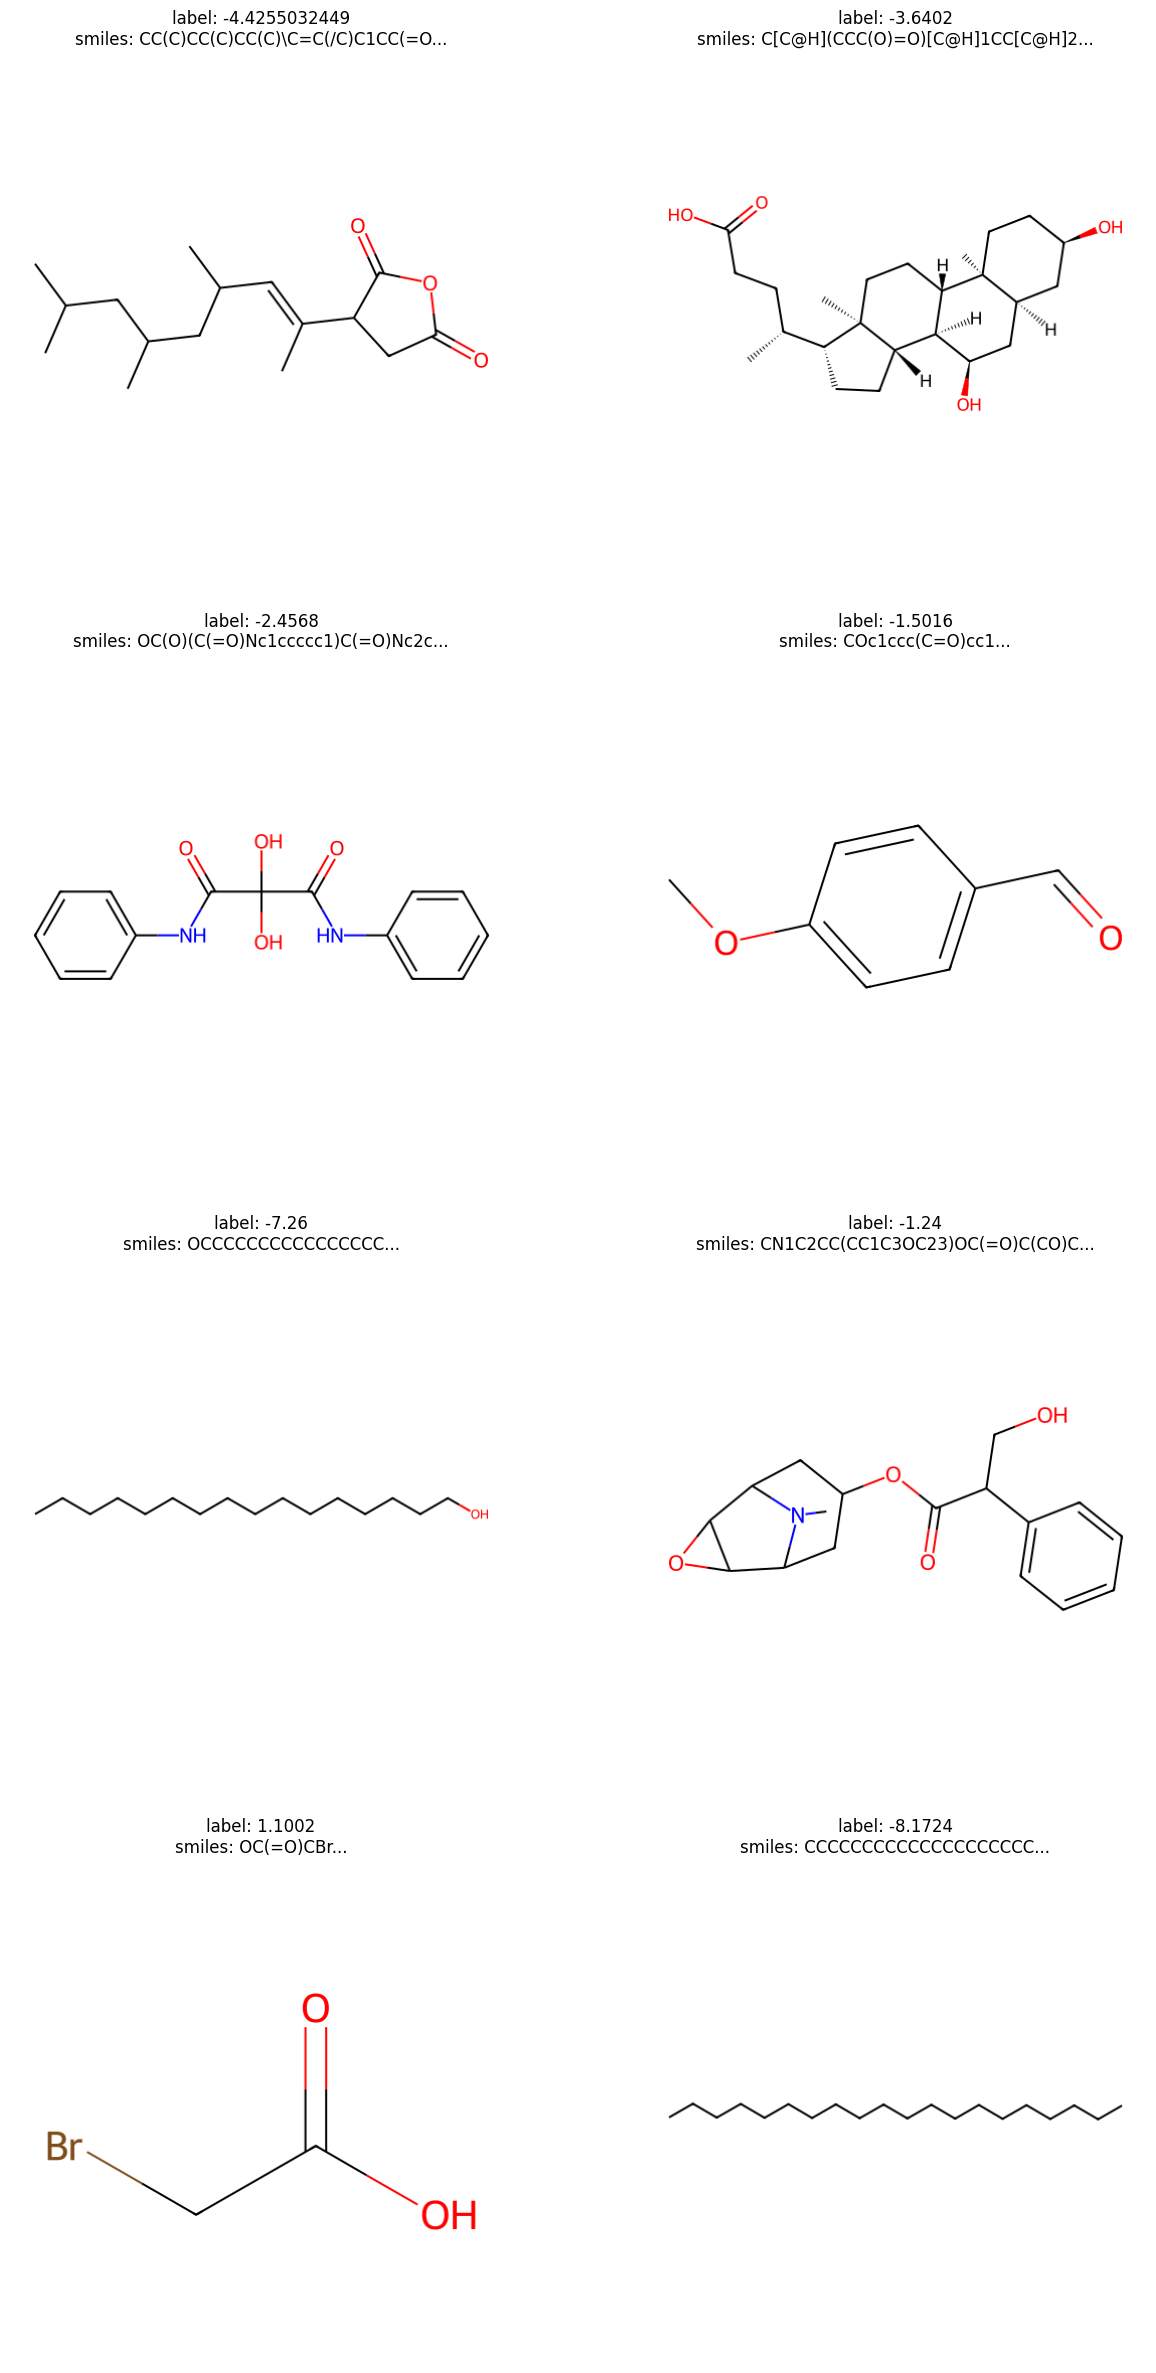

In [60]:
##### DO NOT CHANGE #####

## -- Loading Dataset --
content = nextcloud_download('https://bwsyncandshare.kit.edu/s/9oR8LECtfRZxTLB')
df: pd.DataFrame = pd.read_csv(io.StringIO(content))

## -- Clearning Dataset --
df = df[~df['smiles'].str.contains('\.')]
# Remove rows where the SMILES string cannot be converted to a valid RDKit Mol object
df = df[df['smiles'].apply(lambda s: Chem.MolFromSmiles(s) is not None)].reset_index(drop=True)

print(f'Datasets consists of {len(df)} elements')
print(f'Column names: {", ".join(df.columns)}')
print(f'Dataframe head:')
print(df.head())

## -- Visualizing Examples --
num_examples = 8
indices = random.sample(range(len(df)), k=num_examples)
fig, rows = plt.subplots(
    ncols=2,
    nrows=num_examples // 2,
    figsize=(15, 30),
    squeeze=False,
)

for ax, index in zip(itertools.chain(*rows), indices):
    
    ds = df.iloc[index]
    ax.set_title(f'label: {ds.solubility}\n'
                 f'smiles: {ds.smiles:.30}...')
    mol = Chem.MolFromSmiles(ds.smiles)
    mol_img = Draw.MolToImage(mol, size=(500, 500))
    mol_arr = np.array(mol_img)
    ax.imshow(mol_arr)
    ax.axis('off')

##### DO NOT CHANGE #####

In [61]:
##### DO NOT CHANGE #####
## -- Convert to Graph Dataset --
# The dataframe that we loaded only contains the SMILES representations of the graphs, 
# which cannot be used to train the graph network directly. We first have to convert 
# the SMILES representations for all of those molecules into numeric graph representations 
# first (node attributes and adjacency matrices).

ys = []
graphs = []
for _, ds in df.iterrows():
    try:
        node_attributes, node_adjacency = graph_from_smiles(ds.smiles)
        graphs.append((node_attributes, node_adjacency))
        ys.append(ds.solubility)
    except AttributeError:
        continue
        
print(f'dataset graphs: {len(graphs)}')
print(f'dataset labels: {len(ys)}')

#print(set([n_att.shape for n_att, n_adj in graphs]))
#print(set([n_adj.shape for n_att, n_adj in graphs]))

##### DO NOT CHANGE #####

dataset graphs: 9924
dataset labels: 9924


**Graph Regression.** Our target dataset *AqSolDB* is a *graph regression* dataset which means that we want to predict some sort of continuous value for each individual graph which reflects some property of the corresponding molecule. When we think about our previous GCN implementation, we notice that the update rule only describes how to update the node-level feature matrix $H$. Even after subjecting a graph to multiple graph convolutional steps, the information is still distributed across all its different nodes. To solve a graph regression task, however, we would need the graph-level features. This can done by adding a *global graph pooling* operation. In this step, all the individual node features of a graph are aggregated into single *graph feature vector* $h$ which can then be further processed to solve graph-level prediction tasks.

**Global Sum Pooling.** The most simple pooling operation that we are going to look at here is the *global sum pooling* where the graph feature vector is simply calculated as a sum 

$$
h = \sum_{i \in \mathcal{V}} H_{i,:}
$$

of the individual node feature vectors.

**GCN Implementation.** The following section introduces the ``GCNModel`` class which contains the majority of the implementation that is required to train a GCN-based graph neural network model to solve the given graph regression task. In the first part of the network, multiple GCN layers are applied to refine the node features of the graph. Then a global sum pooling operation is applied to distill the node features into a single feature vector per graph. This graph feature vector is then used as the input to a multi-layer dense neural network which outputs a single value. This single value then acts as the regression output to solve the given water-solubility regression problem.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.7 (2 points).</strong> The following code cell defines the <code>GCNModel</code> class used to solve the AqSolDB water-solubility regression problem. The code is largely complete except for the implementation of the <em>global sum pooling</em> operation. Your task is to implement the <code>pool_nodes</code> function which accepts batched node feature tensor and the batched node feature mask tensor and is supposed to output the batched graph feature tensor!
</div>

In [62]:
class GCNModel(nn.Module):
    """
    Implementation of the graph regression model.
    
    Is constructed with the integer number ``in_dim`` of input node features, 
    the integer number ``hidden_dim`` of hidden units and the desired ``out_dim`` 
    output dimension.
    """
    def __init__(self,
                 in_dim: int, 
                 hidden_dim: int,
                 out_dim: int
                 ):
        super().__init__()
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        
        # These are the actual graph convolutional layers which are applied to the 
        # input graph. Throughout multiple steps, the localized information in each 
        # node is spread and processed throughout the graph, resulting in a final 
        # updated node embedding.
        self.conv_layers = nn.ModuleList([
            utils.GCNConv(in_dim, hidden_dim),
            utils.GCNConv(hidden_dim, hidden_dim),
            utils.GCNConv(hidden_dim, hidden_dim),
        ])
        # The non-linear activation that we'll use after each GCN convolution
        self.lay_act = nn.LeakyReLU()
        
        # A dense network / multi-layer perceptron which then performs the final 
        # regression. Projects the graph embedding of shape (hidden_dim, )
        # into a single float value which is the predicted continuous target 
        # value (e.g. the water solubility).
        self.lay_out = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
        
    def forward(self, 
                node_attributes: torch.Tensor, 
                node_adjacency: torch.Tensor, 
                node_mask: torch.Tensor,
                ) -> torch.Tensor:
        """
        Given the ``node_attributes`` tensor of shape (batch_size, N_max, num_features), the 
        ``node_adjacency`` tensor of shape (batch_size, N_max, N_max) and the ``node_mask`` 
        tensor of the shape (batch_size, N_max, 1), this method performs the forward pass 
        of the model and ultimately predicts the regression output of the shape 
        (batch_size, 1).
        """
        
        node_embedding = node_attributes
        for lay_conv in self.conv_layers:
            node_embedding = lay_conv(
                node_embedding,
                node_adjacency,
                node_mask
            )
            
            node_embedding = self.lay_act(node_embedding)
        
        graph_embedding = self.pool_nodes(
            node_embedding,
            node_mask
        )
        output = self.lay_out(graph_embedding)
        
        return output
    
    # TASK: Implement a global sum pooling operation in the method below.
    
    # HINT: Remember that the node_mask tensor contains a 0/1 binary mask that determines 
    #       which columns of the feature matrix actually contain the feature information.
    
    def pool_nodes(self, 
                   node_embedding: torch.Tensor, 
                   node_mask: torch.Tensor,
                   ) -> torch.Tensor:
        """
        Given the ``node_embedding`` tensor of shape (batch_size, N_max, num_features) and the 
        node mask tensor with the shape (batch_size, N_max, 1), this method applies the 
        global sum pooling operation to return the graph feature vector of shape 
        (batch_size, num_features).
        """
        
        # YOUR CODE HERE
        masked_node_embedding = node_embedding * node_mask
        
        graph_embedding = torch.sum(
            masked_node_embedding,
            dim=1
        )
        
        return graph_embedding

In [63]:
##### DO NOT CHANGE #####
# ID: test-9-7-pooling - possible points: 2

# ~ testing the pooling implementation

_node_attributes = torch.tensor([
    [
        [1, 1, 1, 1],
        [0, 2, 1, 0],
        [0, 1, 3, 1],
    ],
    [
        [0, 2, 3, 5],
        [4, 2, 1, 1],
        [0, 0, 1, 1],
    ]
])
_node_mask = torch.tensor([
    [
        [1],
        [1],
        [1],
    ],
    [
        [1],
        [1],
        [0],
    ]
])

model = GCNModel(4, 4, 2)
_graph_embedding = model.pool_nodes(_node_attributes, _node_mask)

assert isinstance(_graph_embedding, torch.Tensor), 'pooling output needs to be tensor'
assert _graph_embedding.shape == (2, 4), 'node pooling needs to reduce the node dimension'
assert np.isclose(_graph_embedding.numpy(), np.array([
    [1, 4, 5, 2],
    [4, 4, 4, 6],
])).all(), 'pooling implementation is likely incorrect'

# NOTE: There are no additional hidden tests


##### DO NOT CHANGE #####

In [64]:
##### DO NOT CHANGE #####
## -- Train / Test Split --
indices = list(range(len(ys)))
indices_train = random.sample(indices, k=8000)
indices_test = list(set(indices).difference(set(indices_train)))

graphs_train = [graphs[index] for index in indices_train]
graphs_test = [graphs[index] for index in indices_test]

ys_train = [ys[index] for index in indices_train]
ys_test = [ys[index] for index in indices_test]

##### DO NOT CHANGE #####

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.8 (1 point).</strong> In the following code cell your task is to initialize the model for the subsequent training on the AqSolDB data. Choose the input and output dimension according to the dataset properties and the required output characteristics. Use a size of <code>64</code> hidden units.
</div>

In [65]:
# TASK: Initialize the model with the correct arguments to be used for the AqSolDB
#       water-solubility regression problem.

model: GCNModel = None

# YOUR CODE HERE
model = GCNModel(
    in_dim=8,
    hidden_dim=64,
    out_dim=1
)

In [66]:
##### DO NOT CHANGE #####
# ID: test-9-8-model - possible points: 1

assert model is not None
assert isinstance(model, GCNModel)

assert isinstance(model.in_dim, int)
assert hashcheck(str(model.in_dim)) == '2c624232cdd22177'

assert isinstance(model.hidden_dim, int)
assert hashcheck(str(model.hidden_dim)) == 'a68b412c4282555f'

assert isinstance(model.out_dim, int)
assert hashcheck(str(model.out_dim)) == '6b86b273ff34fce1'

# NOTE: The hidden tests will check for the exact values of the model's
#       dimension properties.


##### DO NOT CHANGE #####

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.9 (1 point).</strong> In addition to the model initialization we also need to choose an appropriate value for the <code>N_max</code> parameter that will be used for the graph batching. Based on the given AqSolDB dataset, set <code>N_max</code> to the maximum number of atoms found across all molecules in the dataset. This is the smallest value for which every molecule still fits into the padded batch tensors.
</div>

In [67]:
# TASK: Select a proper N_max value for the given dataset.

N_max: int = None
    
# YOUR CODE HERE
N_max = max(
    node_attributes.shape[0]
    for node_attributes, node_adjacency in graphs
)

In [68]:
##### DO NOT CHANGE #####
# ID: test-9-9-n-max - possible points: 1

assert isinstance(N_max, int), (
    'The max value needs to be an integer!'
)

possible_values = [
    '3f9807cb9ae9fb6c',
    'bc52dd634277c4a3', 
    'e0f05da93a0f5a86', 
    '73d3f1ba062585bc', 
    '80c3cd40fa35f908', 
    'f57e5cb1f4532c00',
]
assert hashcheck(str(N_max)) in possible_values

# NOTE: The hidden tests will check for the exact range of values, which is 
#       the same that is also covered by the hashchecks


##### DO NOT CHANGE #####

In [69]:
##### DO NOT CHANGE #####
# NOTE: This cell trains the model on the CPU and can take several minutes
#       to complete - be patient, it is not stuck.
from sklearn.metrics import r2_score

# ~ training configuration
batch_size = 16
epochs = 10
learning_rate = 1e-3

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ~ model training

history: list[dict] = []

for epoch in range(epochs):
    
    indices_epoch = list(indices_train)
    random.shuffle(indices_epoch)

    # putting the model into training mode
    model.train()
    
    losses_epoch = []
    while indices_epoch:
        
        num = min(batch_size, len(indices_epoch))
        indices_batch, indices_epoch = indices_epoch[:num], indices_epoch[num:]
        
        y_batch = torch.tensor([ys[index] for index in indices_batch], dtype=torch.float32).unsqueeze(-1)
        graphs_batch = [graphs[index] for index in indices_batch]
        
        model.zero_grad()
        
        node_attributes_batch, node_mask_batch, node_adjacency_batch = batch_graphs(graphs_batch, N_max)
        y_pred = model(node_attributes_batch, node_adjacency_batch, node_mask_batch)
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        optimizer.step()
        model.zero_grad()
        
        losses_epoch.append(loss.detach().numpy())
        
    # ~ evaluating the model
    
    # putting the model into evaluation mode (using running averages, etc.)
    model.eval()
    
    node_attributes_test, node_mask_test, node_adjacency_test = batch_graphs(graphs_test, N_max)
    y_pred = model(node_attributes_test, node_adjacency_test, node_mask_test)
    
    r2_epoch = r2_score(ys_test, y_pred.detach().numpy().flatten())
    loss_epoch = np.mean(losses_epoch)
    history.append({
        'r2': r2_epoch,
        'loss': loss_epoch,
    })
    
    print(f' * epoch {epoch:02d}/{epochs} - loss: {loss_epoch:.3f} - r2: {r2_epoch:.3f}')

##### DO NOT CHANGE #####

 * epoch 00/10 - loss: 3.470 - r2: 0.534
 * epoch 01/10 - loss: 2.183 - r2: 0.617
 * epoch 02/10 - loss: 2.088 - r2: 0.609
 * epoch 03/10 - loss: 2.019 - r2: 0.623
 * epoch 04/10 - loss: 1.952 - r2: 0.616
 * epoch 05/10 - loss: 1.878 - r2: 0.527
 * epoch 06/10 - loss: 1.905 - r2: 0.663
 * epoch 07/10 - loss: 1.848 - r2: 0.677
 * epoch 08/10 - loss: 1.784 - r2: 0.670
 * epoch 09/10 - loss: 1.799 - r2: 0.677


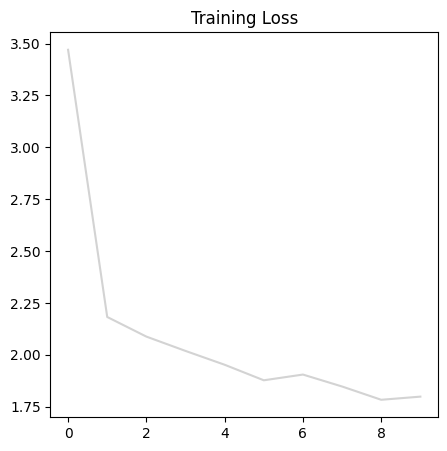

/tmp/ipykernel_1075/2774163770.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


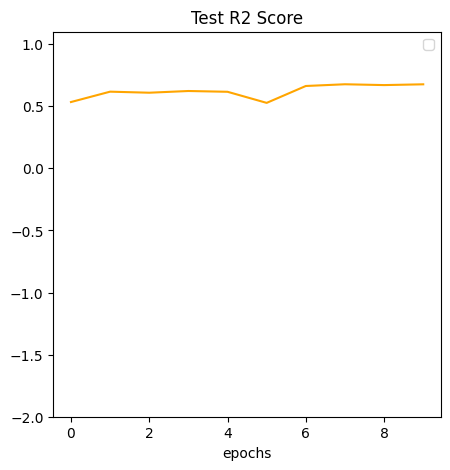

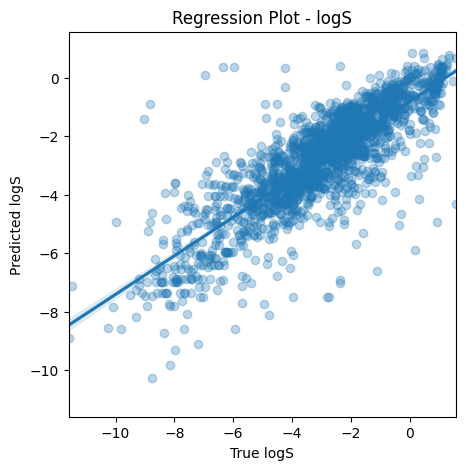

In [70]:
##### DO NOT CHANGE #####
import seaborn as sns

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(5, 5))
ax.set_title('Training Loss')

## -- Plot Training Loss --
ax.plot(
    np.arange(epochs),
    [data['loss'] for data in history],
    color='lightgray',
    label='training loss'
)
plt.show()

fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(5, 5))
ax.set_title('Test R2 Score')

## -- Plot Test R2 --
ax.set_ylim(-2.0, 1.1)
ax.plot(
    np.arange(epochs),
    [data['r2'] for data in history],
    color='orange',
)
ax.legend()
ax.set_xlabel('epochs')

## -- Obtain Model Predictions --
# putting the model into evaluation mode (using running averages, etc.)
model.eval()

node_attributes_test, node_mask_test, node_adjacency_test = batch_graphs(graphs_test, N_max)
y_pred = model(node_attributes_test, node_adjacency_test, node_mask_test)

r2_epoch = r2_score(ys_test, y_pred.detach().numpy().flatten())
# Flatten y_pred to 1D numpy array
y_pred_np = y_pred.detach().numpy().flatten()

y_min = np.min(ys_test)
y_max = np.max(ys_test)

## -- Regression Plot --
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=ys_test, y=y_pred_np, ax=ax, scatter_kws={'alpha':0.3})
ax.set_xlabel('True logS')
ax.set_ylabel('Predicted logS')
ax.set_title('Regression Plot - logS')
ax.set_xlim(y_min, y_max)
ax.set_ylim(y_min, y_max)
plt.show()

##### DO NOT CHANGE #####

## 9.4 📐 Pytorch Geometric

**Modern Graph Learning.** Doing machine learning with graph-structured input faces various challenges, such as the problem of how to properly *batch* graph structures of different sizes. Previously, we've re-implemented one of the most simple approaches based on *padding* and *masking*. However, one obvious disadvantage of the padding approach is the additional memory consumption, where the size of the graph tensors is determined by the largest graph in the batch. For example, if there is a single graph of size 100 among multiple graphs of size ~5-10, most of the memory consumption will be dominated by the padding alone.

As it often is - instead of implementing a solution for such a common problem ourselves, it makes more sense to build upon an existing framework. In the case of graph neural networks, one alternative is to use [Pytorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/).

**Pytorch Geometric.** PyTorch Geometric (PyG) is a popular extension library for PyTorch that is specifically designed for deep learning on irregularly structured data such as graphs and point clouds. PyG provides a wide range of utilities and highly optimized implementations for common graph neural network (GNN) layers, data loaders, and batching mechanisms, making it much easier and more efficient to build, train, and evaluate GNN models. With PyG, users can leverage a variety of state-of-the-art GNN architectures (such as GCN) with minimal code, and benefit from efficient sparse matrix operations and GPU acceleration. The library also includes tools for handling large-scale graph datasets, performing graph-level and node-level tasks, and integrating seamlessly with the broader PyTorch ecosystem.

**Mask and Scatter.** The way in which PyG solves the problem of graph batching is by using *masking* and *scatter* operations as they are efficiently implemented in PyG (via ``torch_geometric.utils.scatter``). Normal, non-scatter operations can only ber performed across a distinct dimension of a tensor. For example, one could calculate the mean over all the values of a dimension like this:


In [71]:
##### DO NOT CHANGE #####
# Mean over last dimension
import torch
values = torch.rand(10, 5)  # shape (10, 5)
avg = torch.mean(values, dim=1)  

# results in a vector with shape (10, )
print(avg.shape)

##### DO NOT CHANGE #####

torch.Size([10])


These kinds of operations can be very efficiently implemented with tensorial data structures. However, this also requires tensors with fixed dimesions, which is not a given with graph-structured input. In contrast to these operations, *scatter* operations can work with any shape by using additional *index* tensors to determine which groups of elements to apply the operation to. In this case, the operation will be applied on all the elements which share the same integer index in the index tensor. The output shape is therefore highly dependent on the *content* of the index tensor and cannot be easily inferred from only the input shapes.

In [72]:
##### DO NOT CHANGE #####
# Mean over arbitrary groups
from torch_geometric.utils import scatter

values = torch.tensor([1, 2, 3, 4, 5], dtype=torch.float32)  # values to be averaged
groups = torch.tensor([0, 0, 1, 1, 1])  # group assignments for each value

mean_per_group = scatter(values, groups, dim=0, reduce='mean')
print(mean_per_group)  # Output: tensor([1.5, 4.0])

##### DO NOT CHANGE #####

tensor([1.5000, 4.0000])


**PyG Data Objects.** PyG uses these scatter operations to implement the graph convolutions as well as the global pooling operations. At the core of the framework is the ``Data`` object which is able to represent individual graphs as well as batches of graphs. One such data object stores the information about a graphs node and edge attributes, it's connectivity information as well as the associated target label(s) (optional). Assuming a graph with $V$ nodes, $E$ edges, $N$ node features, $M$ edge features, a new data object can be constructed with the following arguments:

- ``x`` - a tensor of the shape $(V, N)$ containing the node features for all of the nodes
- ``edge_index`` - a tensor of shape $(2, E)$ consisting of tuples ``(src, dst)`` of integer node indices, where each tuple defines a directed edge between the *src* node to the *dst* node.
- **(optional)** ``edge_attr`` - a tensor of shape $(E, M)$ consisting of the edge attributes for all of the edges defined in the *edge_index* tensor.
- **(optional)** ``pos`` - a tensor of shape $(V, D)$ where $D$ is a dimension in euclidean space. This optional tensor may be used to encode the *positions* of the individual nodes in 2D or 3D space, for example.
- **(optional)** ``y`` - a tensor containing the target value annotations of the given graph.  

In [73]:
##### DO NOT CHANGE #####
from torch_geometric.data import Data

# EXAMPLE: Graph with 3 nodes, connected in a triangle pattern

node_features = torch.tensor([
    [1, 0], # node index 0
    [1, 0], # node index 1
    [0, 1], # node index 2
])

edge_list = torch.tensor([
    [0, 1],
    [1, 2],
    [2, 0]
])

edge_features = torch.tensor([
    [1], # edge index 0
    [1], # edge index 1
    [1]  # edge index 2
])

data = Data(
    x=node_features,
    edge_index=edge_list.t(),
    edge_attr=edge_features,
)

from rich.pretty import pprint
pprint(data)

##### DO NOT CHANGE #####

Data(x=[3, 2], edge_index=[2, 3], edge_attr=[3, 1])

Next, we'll train a model to predict the water solubility of molecules using PyG instead of our own custom implementation.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.10 (2 points).</strong> Your task is to implement the function <code>data_from_smiles</code> function which converts the SMILES string representation of a molecule into a PyG <code>Data</code> instance using the same feature mapping as above. The node features should consist of a one-hot encoding including the following atom types:
<ul>
<li>0 - carbon (C)</li>
<li>1 - nitrogen (N)</li>
<li>2 - oxygen (O)</li>
<li>3 - fluorine (F)</li>
<li>4 - chlorine (Cl)</li>
<li>5 - bromine (Br)</li>
<li>6 - iodine (I)</li>
<li>7 - <em>default case</em> (all others that are none of the above)</li>
</ul>
The <code>edge_index</code> should reflect the bond connections in the molecule and there will be no edge attributes for this exercise.
</div>

In [74]:
def data_from_smiles(smiles: str, y: Optional[float] = None) -> Data:
    """
    Given the ``smiles`` string, this function returns a PyTorch Geometric Data object 
    with the edge indices representing the molecular graph structure and the node features 
    a one-hot encoding of the atom types.
    
    :param smiles: The SMILES representation of the molecule.
    
    :returns: A PyTorch Geometric Data object
    """
    
    mol = Chem.MolFromSmiles(smiles)
    
    # YOUR CODE HERE
    atom_type_indices = {
        "C": 0,
        "N": 1,
        "O": 2,
        "F": 3,
        "Cl": 4,
        "Br": 5,
        "I": 6,
    }
    
    num_atoms = mol.GetNumAtoms()
    
    node_features = torch.zeros(
        (num_atoms, 8),
        dtype=torch.float32
    )
    
    for atom in mol.GetAtoms():
        atom_index = atom.GetIdx()
        atom_symbol = atom.GetSymbol()
        
        feature_index = atom_type_indices.get(atom_symbol, 7)
        node_features[atom_index, feature_index] = 1.0
    
    edges = []
    
    for bond in mol.GetBonds():
        source_index = bond.GetBeginAtomIdx()
        destination_index = bond.GetEndAtomIdx()
        
        # Include both directions because molecular bonds are undirected.
        edges.append([source_index, destination_index])
        edges.append([destination_index, source_index])
    
    if len(edges) > 0:
        edge_index = torch.tensor(
            edges,
            dtype=torch.long
        ).t().contiguous()
    else:
        edge_index = torch.empty(
            (2, 0),
            dtype=torch.long
        )
    
    data = Data(
        x=node_features,
        edge_index=edge_index
    )
    
    if y is not None:
        data.y = torch.tensor(
            [y],
            dtype=torch.float32
        )
    
    return data

In [75]:
##### DO NOT CHANGE #####
# ID: task-9-10-data-smiles - possible points: 2

smiles_example = 'C1=CC=CC=C1CC(CO)C=N' # Molecule with 12 atoms

data_example = data_from_smiles(smiles_example)
assert data_example.x.shape == (12, 8), 'node features shape incorrect'
assert data_example.edge_index.shape == (2, 24), 'edge index shape incorrect'

# A small hand-checkable example: ethanol "CCO" has atoms [C, C, O] (indices
# 0, 1, 2) and bonds 0-1 and 1-2. Each undirected bond becomes two directed
# entries in edge_index, so the set of directed edges is
# {(0, 1), (1, 0), (1, 2), (2, 1)}. The order of the columns does not matter.
_data = data_from_smiles('CCO')
_expected_x = torch.tensor([
    [1, 0, 0, 0, 0, 0, 0, 0],   # atom 0: C
    [1, 0, 0, 0, 0, 0, 0, 0],   # atom 1: C
    [0, 0, 1, 0, 0, 0, 0, 0],   # atom 2: O
], dtype=torch.float32)
assert _data.x.shape == (3, 8), f'node feature shape incorrect: {_data.x.shape}'
assert torch.allclose(_data.x.float(), _expected_x), 'node features incorrect for CCO'
assert _data.edge_index.shape[0] == 2, f'edge_index must have shape (2, num_edges), got {tuple(_data.edge_index.shape)}'
_edges = set(map(tuple, _data.edge_index.t().tolist()))
assert _edges == {(0, 1), (1, 0), (1, 2), (2, 1)}, f'edge_index connectivity incorrect for CCO: {sorted(_edges)}'

# NOTE: The hidden tests additionally compare the node features and the set of
#       edges of the Data object against a reference implementation for several
#       more molecules.


##### DO NOT CHANGE #####

**PyG Dataloaders.** In PyG, a dataset can be created by first obtaining a list of ``Data`` objects representing different graph structures - including those of different sizes. This list of data objects can then be used to construct a ``DataLoader`` object. This data loader object will handle the batching of the dataset automatically in the background. The data loader object can be used like an iterator - meaning that it can be iterated over in a ``for`` loop. Each iteration of this loop will yield a new batch of graphs with the given ``batch_size``.

In each iteration, the data loader will yield an object of the ``Data`` type. However - unlike the original data instances - the data instances yielded by the data loader represent *multiple graphs at once*. These multi-graph data instances have the same properties (``x``, ``edge_index``, ...) in which the properties of the individual graphs are *concatenated* - *not* separated by dimension. For example, for 3 graphs with the 8, 9 and 12 nodes and 10 node features, the shape of the corresponding node tensor would be $(8 + 9 + 12, 10) = (19, 10)$. Crucially, these data instances have the additional ``batch`` attribute which is an *integer index tensor* with a shape corresponding to the combined sum of all the graphs' nodes - in the previous example a tensor of shape $(19, )$. The integer indices in this batch tensor determine which graph each individual node belongs to. Internally, PyG will use this batch tensor to perform the previously introduced *scatter* operations to implement the graph convolutions and the pooling operations.

In [76]:
##### DO NOT CHANGE #####
from torch_geometric.loader import DataLoader

data_list: List[Data] = [
    data_from_smiles('C1=CC=CC=C1CC(CO)C=N'),
    data_from_smiles('CCO'),
    data_from_smiles('C(CN)CCl'),
]

data_loader = DataLoader(
    data_list,
    # This determines the number of graphs that will be compressed into a single batch during each iteration.
    batch_size=2,
    # This flag will determine whether or not the composition of the individual batches will be randomized 
    # every time the DataLoader is iterated over. Setting this to True is crucial for training, but should 
    # be disabled for the evaluation set.
    shuffle=True,
)

# Now we can iterate over the DataLoader in a simple for loop.
for batch in data_loader:
    
    print('')
    print('Data Batch: ', isinstance(batch, Data))
    print('Node Features Shape: ', batch.x.shape)
    print('Edge Index Shape: ', batch.edge_index.shape)
    print('Batch Index Tensor: ', batch.batch.shape)
    pprint(batch.batch)

##### DO NOT CHANGE #####


Data Batch:  True
Node Features Shape:  torch.Size([8, 8])
Edge Index Shape:  torch.Size([2, 12])
Batch Index Tensor:  torch.Size([8])


tensor([0, 0, 0, 0, 0, 1, 1, 1])


Data Batch:  True
Node Features Shape:  torch.Size([12, 8])
Edge Index Shape:  torch.Size([2, 24])
Batch Index Tensor:  torch.Size([12])


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

**📐 Pytorch Geometric & ⚡ Pytorch Lightning.** Previous have introduced [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/) as a framework built on top of pytorch to simplify the training of neural networks in general. We can now leverage the strengths of both Pytorch Lightning and Pytorch Geometric at the same time to streamline the process of working with graph neural networks even more. We do this by creating a new model class which inherits from ``LightningModule`` and internally uses the pre-built graph convolution and global pooling implementations provided by PyG. The only thing we'll have to consider is that both the forward and the backward method now receive a PyG ``Data`` batch as the argument, instead of separate x and y tensors.

By making use of such frameworks we can leverage the improved efficiency and performance of many of the included functionality. For instance, the *GCN* layer that we've looked at so far is one of the very first GNN layers that have been proposed in the literature. Since the introduction of GCN in 2017 many more implementations and variations of graph convolutional layers have been invented and were subsequently included into the base functionality of the Pytorch Geometric library. One example for a slightly more powerful method is the [Graph Isomorphism Network (GIN)](https://arxiv.org/abs/1810.00826).

**Why GIN?** The GCN layer mixes neighbour features with a *fixed* normalized weighted sum ($\hat{D}^{-1/2}\hat{A}\hat{D}^{-1/2}$) followed by a single linear map. The *Graph Isomorphism Network (GIN)* instead takes a plain **sum** over a node's neighbours and feeds it through a small *learnable* multi-layer perceptron. Using a *sum* (rather than a mean or max) is the key design choice: a sum is *injective* over the multiset of neighbour features — it can tell apart neighbourhoods that averaging or max-pooling would collapse to the same value (for example the neighbour sets ``[C, C, O]`` and ``[C, O, O]``). Together with the learnable MLP this makes GIN one of the most *expressive* message-passing architectures, able to distinguish molecular substructures that a plain GCN cannot — which is what we expect to show up as the improved water-solubility predictions further below.

<div style="border: 1px solid #CEB037; border-radius: 3px; padding: 6px; background-color: #faf7e0ff; color: black;">
<strong>🛠️ Task 9.11 (3 points).</strong> Your task is to provide a more sophisticated implementation of the <code>LightningGIN</code> class shown below. This class should make use of both <em>Pytorch Geometric</em> and <em>Pytorch Lightning</em> to provide a graph neural network implementation centered around the <em>GIN</em> layer type. The goal is to apply this model to the same task of water solubility regression as before - hopefully leading to improved results. In total, your model should implement the following architecture.
<ul>
<li><em>3 layers</em> of <code>GINConv</code> layers to perform the graph convolutions and to update the node representations. Each GIN layer should internally employ a <em>2-layer fully connected network</em> using LeakyReLU activations and the given number of <code>hidden_dim</code> dimensions for the intermediate activations. The very first conv layer should accept node feature representations with a dimensionality of <code>in_dim</code>. In detail, the update function of <em>each</em> GIN convolution should implement the following layer structure:
<ul>
<li><code>Linear</code> layer projecting from the input dimension of the previous layer to <code>hidden_dim</code> dimensions</li>
<li><code>BatchNorm1d</code> layer to normalize the output of the previous linear transformation</li>
<li><code>LeakyRelu</code> activation function</li>
<li><code>Linear</code> layer projecting from the <code>hidden_dim</code> dimension to the output dimension going to the next layer</li>
<li><code>BatchNorm1d</code> layer to normalize the output of the previous linear transformation</li>
<li><code>LeakyRelu</code> activation function</li>
</ul></li>
<li>Following the graph convolutions, a <code>SumAggregation</code> should be used to aggregate all of the node embedding vectors into a single graph embedding vector for each graph individually.</li>
<li>On top of the graph embedding, a <em>3-layer fully-connected</em> network should produce an output vector with a dimensionality dictated by <code>out_dim</code>.</li>
</ul>
Note that <em>no additional</em> activation function is applied between the GINConv layers in the <code>forward</code> method &mdash; the LeakyReLU activations already live inside each layer's internal MLP. Concretely, this means that you'll have to implement parts of the <code>__init__</code> and <code>forward</code> methods of the <code>LightningGIN</code> class shown below.
</div>

**💡 Hint.** Make sure to read the [GINConv Documentation](https://pytorch-geometric.readthedocs.io/en/2.5.0/generated/torch_geometric.nn.conv.GINConv.html) and perhaps look up examples of how to use this layer type online.

In [77]:
import pytorch_lightning as pl
from torch_geometric.nn.conv import GINConv
from torch_geometric.nn.aggr import SumAggregation


class LightningGIN(pl.LightningModule):
    """
    Implementation of a 3-layer GIN (Graph Isomorphism Network) model for graph regression tasks.
    
    :param in_dim: The number of input features per node.
    :param hidden_dim: The number of hidden units in the GIN layers and the output MLP.
    :param out_dim: The number of output features (e.g., for regression).
    :param learning_rate: The learning rate for the optimizer.
    """
    
    def __init__(self, 
                 # Your implementation of the model should take into account the following parameters,
                 # which determine the input and output shape, as we ll as the size of the hidden layers
                 # among other things.
                 in_dim: int, 
                 hidden_dim: int, 
                 out_dim: int,
                 learning_rate: float = 1e-3
                 ):
    
        super().__init__()
        self.in_dim = in_dim
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        self.learning_rate = learning_rate
        
        ## -- Convolutional Layers --
        # The following section implements the GIN graph convolutional layers.
        
        # TASK: Initialize the GINConv layers with the appropriate parameters 
        #       as described above.
        # HINT: Make sure that the first convolutional layer takes into account 
        #       the input dimensions of the data (=the number of node features)
        # HINT: Make sure that the last convolutional layer outputs the correct
        #       dimensionality to match the final prediction mlp.
        # YOUR CODE HERE
        self.conv_layers = nn.ModuleList([
            GINConv(
                nn.Sequential(
                    nn.Linear(in_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.LeakyReLU(),
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.LeakyReLU()
                )
            ),
            GINConv(
                nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.LeakyReLU(),
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.LeakyReLU()
                )
            ),
            GINConv(
                nn.Sequential(
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.LeakyReLU(),
                    nn.Linear(hidden_dim, hidden_dim),
                    nn.BatchNorm1d(hidden_dim),
                    nn.LeakyReLU()
                )
            )
        ])
        
        ## -- Global Aggregation --
        # The following layer implements the SumAggregation operation in PyG
        self.lay_pool = SumAggregation()
        
        ## -- Prediction Layers --
        # The following layers implement the final prediction MLP which takes the 
        # aggregated feature embedding for the whole graph and predicts the 
        # graph property (e.g., regression value).
        
        self.lay_out = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
        
    def forward(self, 
                data: Data) -> torch.Tensor:
        """
        Forward pass of the model.
        """
        
        x, edge_index = data.x, data.edge_index
        
        ## -- Convolute Node Embeddings --
        
        # TASK: Apply the graph convolutional layers, which you have defined in the model 
        #       constructor to iteratively update the node embeddings.
        # HINT: Beware to look up which arguments need to be passed to the `GINConv.forward` 
        #       method.
        node_embedding = x
        
        # YOUR CODE HERE
        for lay_conv in self.conv_layers:
            node_embedding = lay_conv(
                node_embedding,
                edge_index
            )
        
        ## -- Global Pooling and Prediction --

        # The pooling operation needs two infos: The individual node feature representations and 
        # the batch index tensor that determines which nodes belong to which graph in the batch.
        graph_embedding = self.lay_pool(node_embedding, data.batch)
        
        # Final prediction
        result = self.lay_out(graph_embedding)
        
        return result
        
    def configure_optimizers(self) -> torch.optim.Optimizer: 
        """
        This method should return the optimizer that will be used to train the model.
        """
        optimizer = torch.optim.Adam(
            self.parameters(), 
            lr=self.learning_rate
        )
        return optimizer
        
    def training_step(self,
                      batch: Data
                      ) -> torch.Tensor:
        """
        Given the ``batch`` of graph data, this method should calculate and return the 
        loss value which will then be used to calculate the gradients and perform the 
        backpropagation step.
        """
        
        y_pred = self.forward(batch)
        y_true = batch.y.view_as(y_pred)
        loss = F.mse_loss(y_pred, y_true)
        self.log(
            'train_loss', 
            loss, 
            on_step=True, 
            on_epoch=True, 
            prog_bar=True,
            batch_size=torch.max(batch.batch).numpy() + 1
        )
        
        return loss

In [78]:
##### DO NOT CHANGE #####
# ID: task-9-11-construction - possible points: 1

from torch_geometric.nn.conv import GINConv

model = LightningGIN(
    in_dim=8,
    hidden_dim=64,
    out_dim=1,
    learning_rate=1e-3,
)

## -- General Model --
assert isinstance(model, pl.LightningModule), 'model needs to inherit from the pl.LightningModule class!'

## -- Parameter Check --
# If the instructions for the model initialization were followed correctly then the model should have 
# AT LEAST the following number of parameters
num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Number of trainable parameters: {num_parameters}')
assert num_parameters >= 25_000, 'Your model has too few trainable parameters! please double check your model architecture.'

# -- Layer Check --
# Here we just check on the surface level that the model contains the expected layers as defined in the 
# task description.

def count_layers(module: pl.LightningModule, layer_type: type, ignore_type: type = None) -> int:
    count = 0
    if isinstance(module, layer_type):
        count += 1
        
    if ignore_type is not None and isinstance(module, ignore_type):
        return count
    
    for child in module.children():
        count += count_layers(child, layer_type, ignore_type)
    
    return count

# Check for at least 3 GINConv layers in the model (recursively)
num_ginconv_layers = count_layers(model, GINConv)
print(f'Number of GINConv layers: {num_ginconv_layers}')
assert num_ginconv_layers >= 3, 'Model must contain at least 3 GINConv layers!'

# NOTE: There are no additional hidden tests for the model architecture


##### DO NOT CHANGE #####

Number of trainable parameters: 30785
Number of GINConv layers: 3


In [79]:
##### DO NOT CHANGE #####
# ID: task-9-11-function - possible points: 1

model = LightningGIN(
    in_dim=8,
    hidden_dim=32,
    out_dim=2,
    learning_rate=1e-3,
)

data_example: Data = data_from_smiles(smiles_example, y=[0.5, 0.8])
# This is a shorthand to convert a single-graph data object into a batch of size 1 because the 
# input of the forward method will always have to be batched data instances.
batch_example = next(iter(DataLoader([data_example, data_example], batch_size=2)))

## -- Checking Forward Pass --

output = model(batch_example)

assert isinstance(output, torch.Tensor), 'model forward pass should return a tensor!'
# The output shape should be (batch_size, out_dim), where batch_size is 1 in this case and the 
# out_dim is 2 as specified in the model initialization.
print('output shape:', output.shape)
assert output.shape == (2, 2), f'model forward pass should return a tensor of shape (2, 2), got {output.shape}'

## -- Checking Training Step --

batch_example.x.requires_grad = True
loss = model.training_step(batch_example)
assert isinstance(loss, torch.Tensor), 'model training_step should return a tensor!'
# The loss should be a scalar tensor, i.e., it should have no dimensions or be of shape ().
print('loss shape:', loss.shape)
assert loss.shape == (), f'model training_step should return a scalar loss tensor, got {loss.shape}'

loss.backward()
# Check if gradients are computed
print('node features gradient shape:', batch_example.x.grad.shape)
assert batch_example.x.grad is not None, 'model training_step should compute gradients for the input features!'

# NOTE: There are no additional hidden tests

##### DO NOT CHANGE #####

output shape: torch.Size([2, 2])
loss shape: torch.Size([])
node features gradient shape: torch.Size([24, 8])


/opt/conda/lib/python3.12/site-packages/pytorch_lightning/core/module.py:451: You are trying to `self.log()` but the `self.trainer` reference is not registered on the model yet. This is most likely because the model hasn't been passed to the `Trainer`


In [80]:
##### DO NOT CHANGE #####
# ID: task-9-11-training - possible points: 1

model = LightningGIN(
    in_dim=8,
    hidden_dim=64,
    out_dim=1,
    learning_rate=1e-3,
)
# In the beginning there should be no gradients computed for the model parameters
params = [p for p in model.parameters() if p.requires_grad]
grads_exist = any((p.grad is None or torch.all(p.grad == 0)) for p in params)
assert grads_exist, "Model parameters were not updated during training. Training may have failed."

# Select 100 random SMILES strings from the dataframe
sample_indices = random.sample(range(len(df)), 100)
smiles_list_example = df.iloc[sample_indices].smiles.tolist()
solubility_list_example = df.iloc[sample_indices].solubility.tolist()
data_list_example = [data_from_smiles(smiles, y=value) for smiles, value in zip(smiles_list_example, solubility_list_example)]
data_loader_example = DataLoader(
    data_list_example,
    batch_size=16,
    shuffle=True,
)


import logging

# Suppress all logs from Lightning below CRITICAL
logging.getLogger("pytorch_lightning").setLevel(logging.CRITICAL)

# Optionally suppress any 3rd-party noisy loggers
logging.getLogger("lightning").setLevel(logging.CRITICAL)
logging.getLogger("torch").setLevel(logging.CRITICAL)

trainer = pl.Trainer(
    max_steps=3,
    logger=False,
    accelerator='cpu',
    enable_progress_bar=False,
)
trainer.fit(model, data_loader_example)

# Assert that model parameters have been updated (i.e., gradients exist and are not all zero)
params = [p for p in model.parameters() if p.requires_grad]
grads_exist = any((p.grad is not None and torch.any(p.grad != 0)) for p in params)
assert grads_exist, "Model parameters were not updated during training. Training may have failed."

# NOTE: There are no additional hidden tests

##### DO NOT CHANGE #####

/opt/conda/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/jovyan/work/__repository/exercises/checkpoints exists and is not empty.


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv_layers │ ModuleList     │ 22.1 K │ train │     0 │
│ 1 │ lay_pool    │ SumAggregation │      0 │ train │     0 │
│ 2 │ lay_out     │ Sequential     │  8.6 K │ train │     0 │
└───┴─────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 30.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.8 K                                                                                               
Total estimated model params size (MB): 0.123                                                                      
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/opt/conda/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/conda/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=127` in the `DataLoader` to improve performance.


Now we can train the final model of this exercise and see if it performed any better than our own GCN implementation!

In [ ]:
##### DO NOT CHANGE #####
# NOTE: This cell trains the model for 10 epochs on the CPU and can take several
#       minutes. The progress bar is disabled, so there is little output while
#       an epoch is running - the cell is not stuck.
from sklearn.metrics import r2_score

model = LightningGIN(
    in_dim=8, 
    hidden_dim=64, 
    out_dim=1,
)

## -- Splitting the Dataset --
smiles_train = df.iloc[indices_train].smiles
targets_train = df.iloc[indices_train].solubility

data_list_train = [data_from_smiles(smi, y=tgt) for smi, tgt in zip(smiles_train, targets_train)]
train_loader = DataLoader(data_list_train, batch_size=32, shuffle=True)

smiles_test = df.iloc[indices_test].smiles
targets_test = df.iloc[indices_test].solubility

data_list_test = [data_from_smiles(smi, y=tgt) for smi, tgt in zip(smiles_test, targets_test)]
test_loader = DataLoader(data_list_test, batch_size=32, shuffle=False)

## -- Splitting the Dataset --
test_callback = utils.ProgressCallback(test_loader)
trainer = pl.Trainer(
    max_epochs=10,
    callbacks=[test_callback],
    accelerator='cpu',
    enable_progress_bar=False,
)
trainer.fit(model, train_loader)

##### DO NOT CHANGE #####

┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv_layers │ ModuleList     │ 22.1 K │ train │     0 │
│ 1 │ lay_pool    │ SumAggregation │      0 │ train │     0 │
│ 2 │ lay_out     │ Sequential     │  8.6 K │ train │     0 │
└───┴─────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 30.8 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 30.8 K                                                                                               
Total estimated model params size (MB): 0.123                                                                      
Modules in train mode: 37                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Test R2 after epoch 0: -1.850
Test R2 after epoch 1: 0.680
Test R2 after epoch 2: 0.710
Test R2 after epoch 3: 0.730
Test R2 after epoch 4: 0.732
Test R2 after epoch 5: 0.754
Test R2 after epoch 6: 0.784
Test R2 after epoch 7: 0.751
Test R2 after epoch 8: 0.781
Test R2 after epoch 9: 0.765


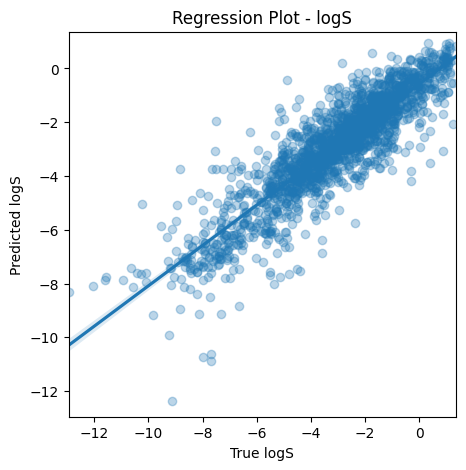

In [41]:
##### DO NOT CHANGE #####
## -- Obtaining Model Predictions --
# putting the model into evaluation mode (using running averages, etc.)
model.eval()

ys_pred = []
ys_test = np.array(list(targets_test), dtype=np.float32)
for batch in test_loader:
    y_pred = model(batch)
    ys_pred.append(y_pred.detach().numpy())
    
ys_pred = np.concatenate(ys_pred, axis=0).squeeze()
r2_value = r2_score(ys_test, ys_pred)

y_min = np.min(ys_test)
y_max = np.max(ys_test)

## -- Regression Plot --
fig, ax = plt.subplots(figsize=(5, 5))
sns.regplot(x=ys_test, y=ys_pred, ax=ax, scatter_kws={'alpha':0.3})
ax.set_xlabel('True logS')
ax.set_ylabel('Predicted logS')
ax.set_title('Regression Plot - logS')
ax.set_xlim(y_min, y_max)
ax.set_ylim(y_min, y_max)
plt.show()

##### DO NOT CHANGE #####

Something that you'll likely notice here is that this model achieves a much better final performance than our homebrew GCN implementation! More importantly, you'll see improved *training dynamics* - both in terms of how fast it converges and how much the loss jumps in each iteration.

---

👋 This concludes the exercise about *graph neural networks*. Hopefully you've gained some additional understanding about the ideas behind the practical implementations of GNNs and how they can be used for molecular property predictions in chemistry and material science. Ultimately, this exercise sheet has only scratched the surface of vast research domain that has been largely initiated by Kipf & Welling's GCN implementation. If you are interested in this topic, feel free to also check out the survey paper published by our research group: https://www.nature.com/articles/s43246-022-00315-6